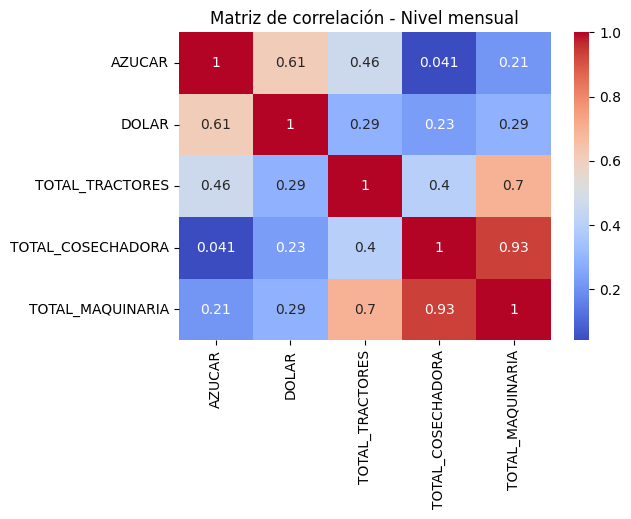

Correlaciones:
Bimestral: ('Bimestral', np.float64(0.2123298945131073))
Trimestral: ('Trimestral', np.float64(0.4256947411136493))
Cuatrimestral: ('Cuatrimestral', np.float64(0.2123298945131073))
      Frecuencia        R2    Coef_Azucar  P_Azucar
0        Mensual  0.045084  141016.282717  0.058642
1      Bimestral  0.045084  141016.282717  0.058642
2     Trimestral  0.181216  545875.822661  0.026840
3  Cuatrimestral  0.045084  141016.282717  0.058642

M0: Sin rezago
                            OLS Regression Results                            
Dep. Variable:       TOTAL_MAQUINARIA   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     5.533
Date:                Thu, 20 Nov 2025   Prob (F-statistic):             0.0268
Time:                        22:11:16   Log-Likelihood:                -453.32
No. Observations:                  27   AIC:          

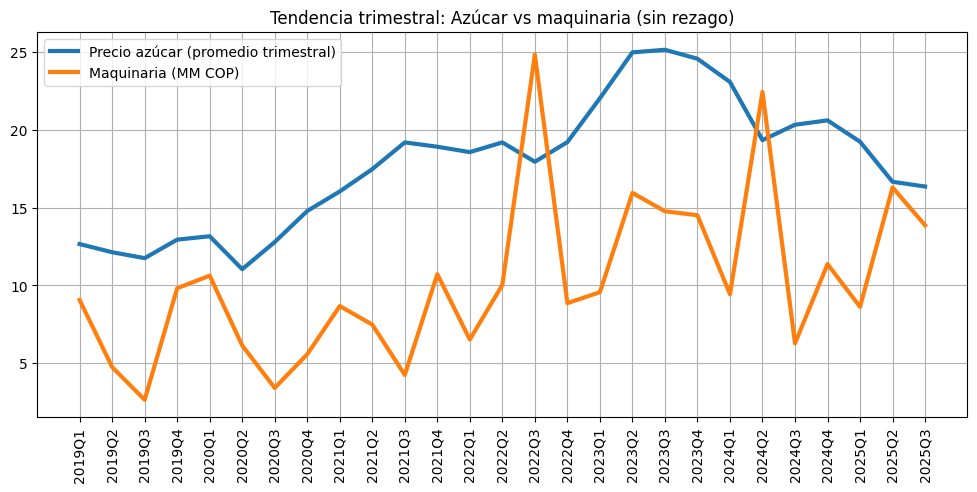

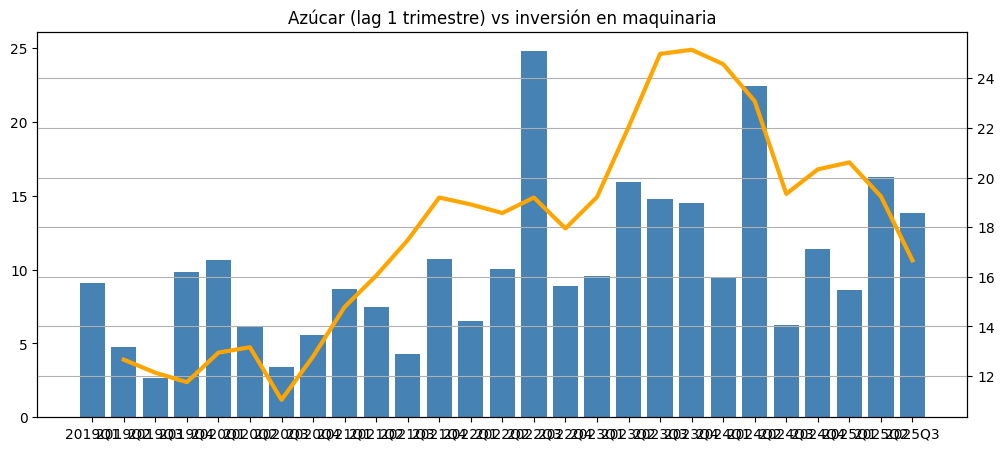

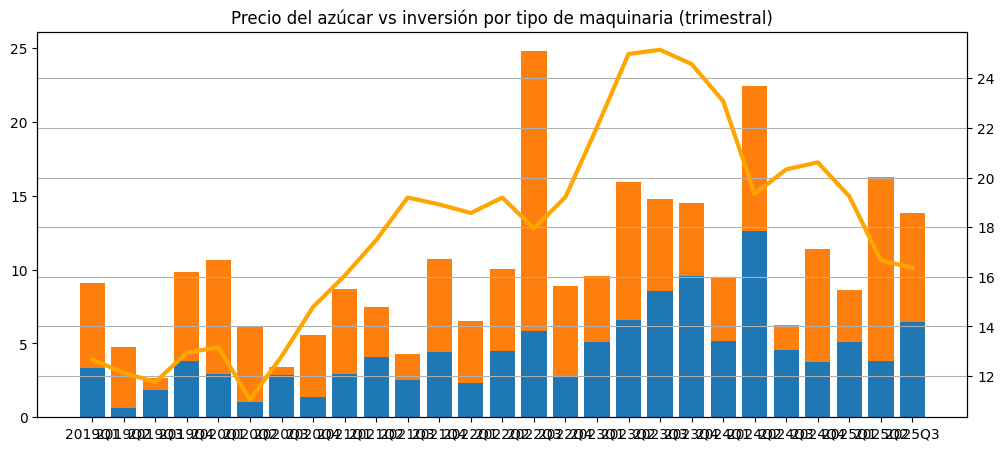

In [12]:
# =========================================
# 📌 1. Importar librerías
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# =========================================
# 📌 2. Cargar archivo CSV (con codificación correcta)
# =========================================
file_path = "csv_tractores.csv"

df = pd.read_csv(file_path, encoding="latin-1")

# Limpiar nombres de columnas (mayúsculas y sin espacios)
df.columns = df.columns.str.strip().str.upper()

# Renombrar DÓLAR → DOLAR si viene con tilde
df = df.rename(columns={"DÓLAR": "DOLAR"})


# =========================================
# 📌 3. Convertir FECHA a tipo datetime
# =========================================
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")


# =========================================
# 📌 4. Limpiar valores numéricos
# Removemos $, espacios, comas, y reemplazamos "-" con NaN
# =========================================
for col in df.columns:
    if col != "FECHA":
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        df[col] = df[col].replace("-", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")


# =========================================
# 📌 5. Crear métricas totales
# =========================================
df["TOTAL_TRACTORES"] = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"] = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]


# =========================================
# 📌 6. Crear periodos: mensual, bimestral, trimestral, cuatrimestral
# =========================================
df["MES"] = df["FECHA"].dt.to_period("M")
df["BIMESTRE"] = df["FECHA"].dt.to_period("2M")
df["TRIMESTRE"] = df["FECHA"].dt.to_period("Q")
df["CUATRIMESTRE"] = df["FECHA"].dt.to_period("4M")


# =========================================
# 📌 7. Función para agregar datos por periodo
# =========================================
def aggregate_by(col):
    return df.groupby(col).agg({
        "AZUCAR": "mean",
        "DOLAR": "mean",
        "TOTAL_TRACTORES": "sum",
        "TOTAL_COSECHADORA": "sum",
        "TOTAL_MAQUINARIA": "sum"
    }).reset_index()


# Crear tablas agregadas
df_mes = aggregate_by("MES")
df_bi = aggregate_by("BIMESTRE")
df_trim = aggregate_by("TRIMESTRE")
df_cuat = aggregate_by("CUATRIMESTRE")


# =========================================
# 📌 8. Correlación general (nivel mensual)
# =========================================
corr_month = df_mes[["AZUCAR","DOLAR","TOTAL_TRACTORES","TOTAL_COSECHADORA","TOTAL_MAQUINARIA"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_month, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación - Nivel mensual")
plt.show()


# =========================================
# 📌 9. Comparación de correlaciones por frecuencia
# =========================================
def corr_pair(df_agg, label):
    c = df_agg[["AZUCAR","TOTAL_MAQUINARIA"]].corr().iloc[0,1]
    return (label, c)

print("Correlaciones:")
print("Bimestral:", corr_pair(df_bi,"Bimestral"))
print("Trimestral:", corr_pair(df_trim,"Trimestral"))
print("Cuatrimestral:", corr_pair(df_cuat,"Cuatrimestral"))


# =========================================
# 📌 10. Modelos estadísticos simples por frecuencia
# =========================================
def reg_simple(df_agg, freq_label):
    data = df_agg[["TOTAL_MAQUINARIA","AZUCAR"]].dropna()
    X = sm.add_constant(data["AZUCAR"])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y,X).fit()
    return {
        "Frecuencia": freq_label,
        "R2": model.rsquared,
        "Coef_Azucar": model.params["AZUCAR"],
        "P_Azucar": model.pvalues["AZUCAR"]
    }

print(pd.DataFrame([
    reg_simple(df_mes,"Mensual"),
    reg_simple(df_bi,"Bimestral"),
    reg_simple(df_trim,"Trimestral"),
    reg_simple(df_cuat,"Cuatrimestral")
]))


# =========================================
# 📌 11. Modelos con rezagos (solo trimestral)
# =========================================
df_trim_lag = df_trim.copy()
df_trim_lag["AZUCAR_LAG1"] = df_trim_lag["AZUCAR"].shift(1)
df_trim_lag["AZUCAR_LAG2"] = df_trim_lag["AZUCAR"].shift(2)


def run_model(df_lag, predictors, label):
    data = df_lag[["TOTAL_MAQUINARIA"] + predictors].dropna()
    X = sm.add_constant(data[predictors])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y,X).fit()
    print("\n==========================")
    print(label)
    print(model.summary())
    print("==========================\n")


# Modelos probados
run_model(df_trim_lag, ["AZUCAR"], "M0: Sin rezago")
run_model(df_trim_lag, ["AZUCAR_LAG1"], "M1: Lag 1 trimestre")
run_model(df_trim_lag, ["AZUCAR_LAG2"], "M2: Lag 2 trimestres")
run_model(df_trim_lag, ["AZUCAR_LAG1","AZUCAR_LAG2"], "M3: Lag1 + Lag2")
run_model(df_trim_lag, ["AZUCAR_LAG1","DOLAR"], "M4: Lag1 + DOLAR")


# =========================================
# 📌 12. Gráficos
# =========================================

# --- Gráfico trimestral sin rezago ---
plt.figure(figsize=(12,5))
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR"], label="Precio azúcar (promedio trimestral)", linewidth=3)
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_MAQUINARIA"]/1e6, label="Maquinaria (MM COP)", linewidth=3)
plt.xticks(rotation=90)
plt.title("Tendencia trimestral: Azúcar vs maquinaria (sin rezago)")
plt.legend()
plt.grid(True)
plt.show()


# --- Gráfico con rezago ---
plt.figure(figsize=(12,5))
plt.bar(df_trim_lag["TRIMESTRE"].astype(str), df_trim_lag["TOTAL_MAQUINARIA"]/1e6, color="steelblue", label="Maquinaria (MM COP)")
ax2 = plt.twinx()
ax2.plot(df_trim_lag["TRIMESTRE"].astype(str), df_trim_lag["AZUCAR_LAG1"], color="orange", linewidth=3, label="Azúcar Lag 1")
plt.xticks(rotation=90)
plt.title("Azúcar (lag 1 trimestre) vs inversión en maquinaria")
plt.grid(True)
plt.show()


# --- Gráfico por tipo de maquinaria ---
plt.figure(figsize=(12,5))
plt.bar(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_TRACTORES"]/1e6, label="Tractores (MM COP)")
plt.bar(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_COSECHADORA"]/1e6, bottom=df_trim["TOTAL_TRACTORES"]/1e6, label="Cosechadoras (MM COP)")
ax2 = plt.twinx()
ax2.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR"], color="orange", linewidth=3, label="Precio azúcar")
plt.xticks(rotation=90)
plt.title("Precio del azúcar vs inversión por tipo de maquinaria (trimestral)")
plt.grid(True)
plt.show()



=== Primeras filas de la data cruda limpia ===
       FECHA    DOLAR  AZUCAR  TOT_COSECHADORA  TOT_COSECHA_CASE  \
0 2019-01-01  3103.25   12.73       1702863.63        1702863.63   
1 2019-02-01  3080.25   12.73              NaN               NaN   
2 2019-03-01  3186.03   12.53       1148713.83        1148713.83   
3 2019-04-01  3231.25   11.99       1174704.15        1174704.15   
4 2019-05-01  3375.00   12.10              NaN               NaN   

   TOT_TRACTORES7000  TOT_TRACTORES7000_CASE  SUMA_TRACTOR_COSECHADORA  
0          239755.20               133465.73                1942618.83  
1          684983.60               439023.27                 684983.60  
2         1175085.83               693708.90                2323799.66  
3          130220.75                     NaN                1304924.90  
4          181115.61                     NaN                 181115.61   

=== Matriz de correlación mensual ===
                   AZUCAR  DOLAR  TOTAL_TRACTORES  TOTAL_COSECHADO

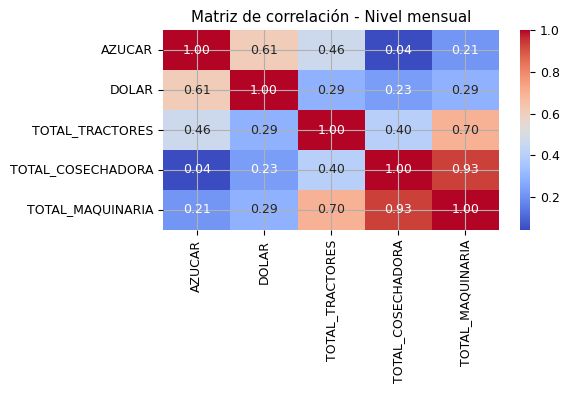

=== Correlación AZUCAR vs TOTAL_MAQUINARIA por frecuencia ===
Bimestral : 0.212
Trimestral: 0.426
Cuatrimestral: 0.212 

=== Tabla comparativa de modelos por frecuencia (TOTAL_MAQUINARIA ~ AZUCAR) ===
      Frecuencia  N_periodos      R2  Coef_Azucar  P_Azucar
0        Mensual          80  0.0451  141016.2827    0.0586
1      Bimestral          80  0.0451  141016.2827    0.0586
2     Trimestral          27  0.1812  545875.8227    0.0268
3  Cuatrimestral          80  0.0451  141016.2827    0.0586 

=== Tabla de modelos con rezagos (trimestral) ===
                 Modelo  N_obs      R2  Coef_principal  P_valor_principal
0        M0: sin rezago     27  0.1812     545875.8227             0.0268
1   M1: lag 1 trimestre     26  0.3313     739085.7651             0.0021
2  M2: lag 2 trimestres     25  0.2580     639060.5693             0.0095
3       M3: lag1 + lag2     25  0.3058     743450.3631             0.2316
4      M4: lag1 + DOLAR     26  0.3544     607152.5767             0.0284 

=

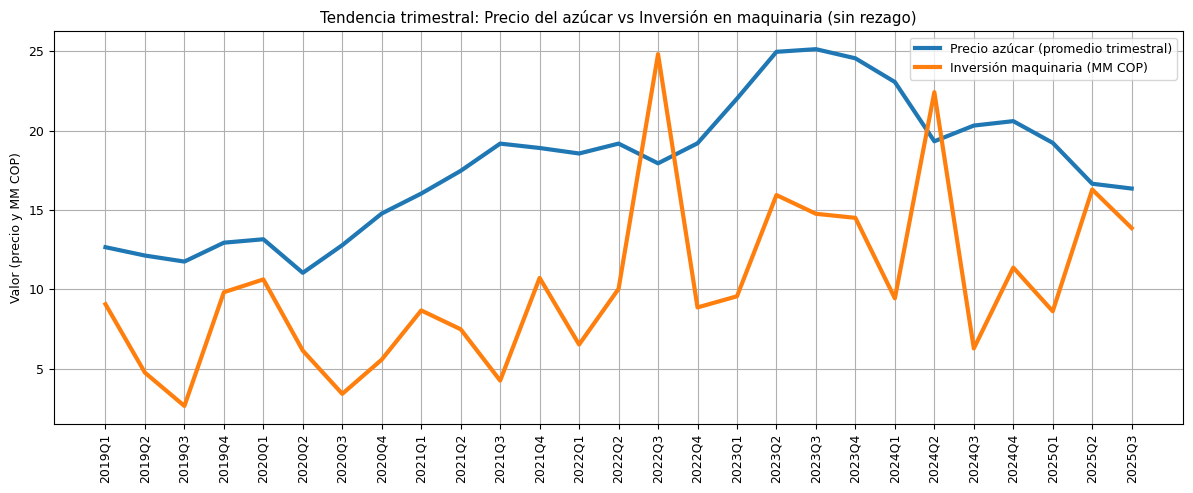

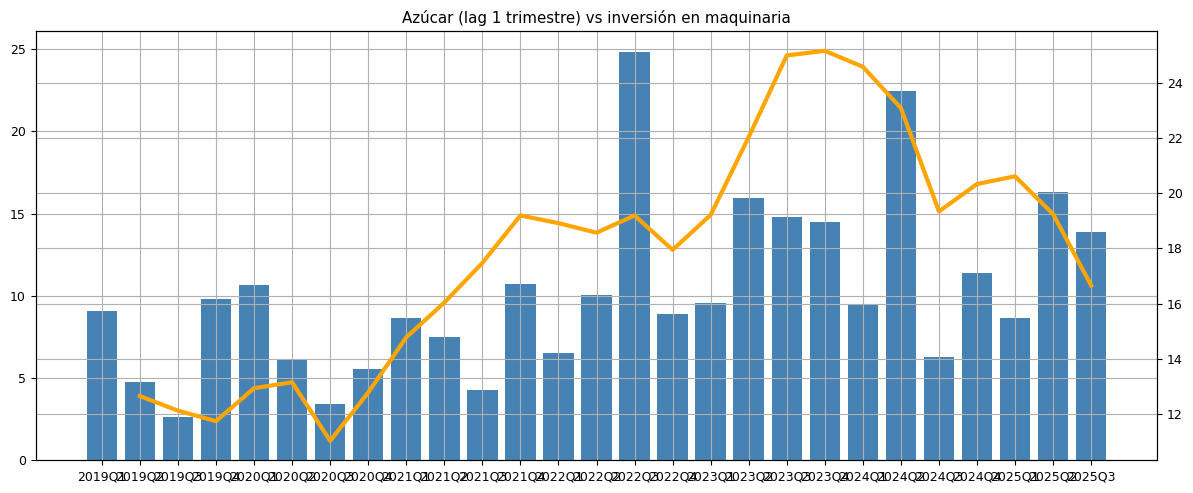

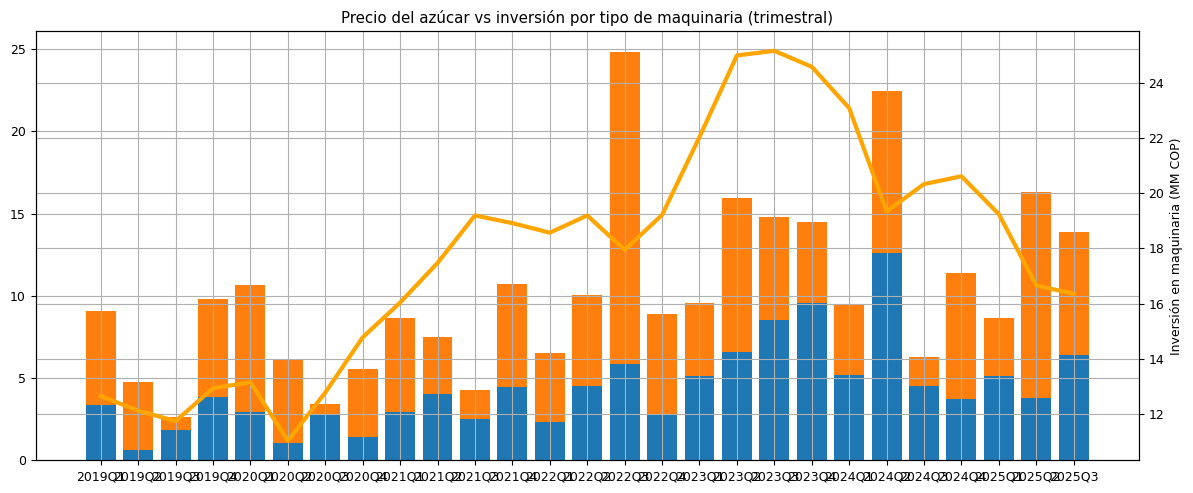

C:\Users\andres.hernandez\AppData\Local\Temp\ipykernel_39232\1699238290.py:316: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x, rotation=90)


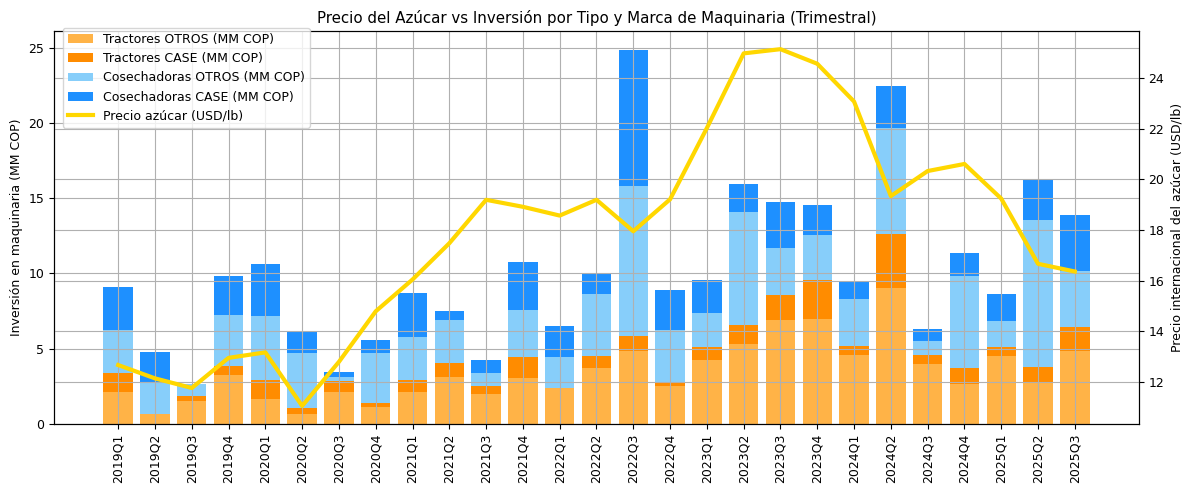

=== MENSAJE EJECUTIVO PARA GERENCIA ===

1) El modelo trimestral TOTAL_MAQUINARIA ~ AZUCAR tiene un R² de aproximadamente 0.181 y un p-valor significativo (< 0.05), lo que indica que el precio del azúcar explica una parte importante de la inversión total en maquinaria.

2) Al introducir rezagos trimestrales, el mejor desempeño se obtiene con el modelo TOTAL_MAQUINARIA ~ AZUCAR_LAG1, con R² alrededor de 0.331 y p-valor muy bajo para el coeficiente del azúcar rezagado (alta significancia estadística).

3) Esto respalda la hipótesis de que los ingenios azucareros toman decisiones de inversión en maquinaria con un rezago cercano a un trimestre: primero se materializan mejores precios, luego llega la decisión de CAPEX.

4) Los gráficos por tipo y marca de maquinaria muestran que los picos de inversión, especialmente en cosechadoras y tractores CASE, coinciden con periodos de altos precios del azúcar, lo que sugiere que CASE captura una mayor parte de la inversión en ciclos expansivos del se

In [13]:
# ============================================================
# ANALISIS COMPLETO: AZÚCAR vs VENTAS DE MAQUINARIA (TRACTORES + COSECHADORAS)
# Incluye:
#   - Limpieza del CSV
#   - Agregaciones: mensual, bimestral, trimestral, cuatrimestral
#   - Correlaciones
#   - Modelos OLS (sin lag y con lag)
#   - Gráficos: totales y discriminación CASE vs otros
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 9

# ------------------------------------------------------------
# 1. CARGA Y LIMPIEZA DEL CSV
# ------------------------------------------------------------

FILE_PATH = "csv_tractores.csv"   # <-- ajusta si tu archivo tiene otro nombre

# El archivo viene en latin-1 por el carácter "Ó" en "DÓLAR"
df = pd.read_csv(FILE_PATH, encoding="latin-1")

# Normalizar nombres de columnas: quitar espacios y poner mayúsculas
df.columns = df.columns.str.strip().str.upper()

# Renombrar "DÓLAR" a "DOLAR" si existe
df = df.rename(columns={"DÓLAR": "DOLAR"})

# Convertir FECHA a datetime (formato DD/MM/YYYY)
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# Limpiar todas las columnas numéricas
for col in df.columns:
    if col != "FECHA":
        # Quitar espacios, símbolos y normalizar decimales
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.replace(",", ".", regex=False)
        )
        # Reemplazar "-" por NaN
        df[col] = df[col].replace("-", np.nan)
        # Convertir a float
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("=== Primeras filas de la data cruda limpia ===")
print(df.head(), "\n")


# ------------------------------------------------------------
# 2. CREAR TOTALES Y VARIABLES POR MARCA
# ------------------------------------------------------------

# Totales por tipo de máquina
df["TOTAL_TRACTORES"] = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"] = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]

# Desagregación por marca y tipo
df["TRACTORES_OTROS"] = df["TOT_TRACTORES7000"].fillna(0)
df["TRACTORES_CASE"] = df["TOT_TRACTORES7000_CASE"].fillna(0)
df["COSECHADORAS_OTROS"] = df["TOT_COSECHADORA"].fillna(0)
df["COSECHADORAS_CASE"] = df["TOT_COSECHA_CASE"].fillna(0)


# ------------------------------------------------------------
# 3. CREAR PERIODOS: MENSUAL, BIMESTRAL, TRIMESTRAL, CUATRIMESTRAL
# ------------------------------------------------------------

df["MES"] = df["FECHA"].dt.to_period("M")
df["BIMESTRE"] = df["FECHA"].dt.to_period("2M")
df["TRIMESTRE"] = df["FECHA"].dt.to_period("Q")
df["CUATRIMESTRE"] = df["FECHA"].dt.to_period("4M")


def aggregate_by(col_periodo: str) -> pd.DataFrame:
    """
    Agrega por periodo (MES, BIMESTRE, TRIMESTRE, CUATRIMESTRE)
    utilizando promedio de azúcar/TRM y sumas de montos.
    """
    return df.groupby(col_periodo).agg({
        "AZUCAR": "mean",
        "DOLAR": "mean",
        "TOTAL_TRACTORES": "sum",
        "TOTAL_COSECHADORA": "sum",
        "TOTAL_MAQUINARIA": "sum"
    }).reset_index()


df_mes = aggregate_by("MES")
df_bi = aggregate_by("BIMESTRE")
df_trim = aggregate_by("TRIMESTRE")
df_cuat = aggregate_by("CUATRIMESTRE")


# ------------------------------------------------------------
# 4. MATRIZ DE CORRELACIÓN (NIVEL MENSUAL)
# ------------------------------------------------------------

corr_month = df_mes[["AZUCAR", "DOLAR", "TOTAL_TRACTORES", "TOTAL_COSECHADORA", "TOTAL_MAQUINARIA"]].corr()

print("=== Matriz de correlación mensual ===")
print(corr_month.round(3), "\n")

plt.figure(figsize=(6, 4))
sns.heatmap(corr_month, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación - Nivel mensual")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. CORRELACIÓN SIMPLE AZÚCAR vs MAQUINARIA POR FRECUENCIA
# ------------------------------------------------------------

def corr_pair(df_agg: pd.DataFrame, label: str):
    c = df_agg[["AZUCAR", "TOTAL_MAQUINARIA"]].corr().iloc[0, 1]
    return label, c

corr_bi = corr_pair(df_bi, "Bimestral")
corr_trim = corr_pair(df_trim, "Trimestral")
corr_cuat = corr_pair(df_cuat, "Cuatrimestral")

print("=== Correlación AZUCAR vs TOTAL_MAQUINARIA por frecuencia ===")
print("Bimestral :", round(corr_bi[1], 3))
print("Trimestral:", round(corr_trim[1], 3))
print("Cuatrimestral:", round(corr_cuat[1], 3), "\n")


# ------------------------------------------------------------
# 6. MODELO SIMPLE POR FRECUENCIA: TOTAL_MAQUINARIA ~ AZUCAR
# ------------------------------------------------------------

def reg_simple(df_agg: pd.DataFrame, freq_label: str) -> dict:
    data = df_agg[["TOTAL_MAQUINARIA", "AZUCAR"]].dropna()
    X = sm.add_constant(data["AZUCAR"])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y, X).fit()
    return {
        "Frecuencia": freq_label,
        "N_periodos": len(data),
        "R2": model.rsquared,
        "Coef_Azucar": model.params["AZUCAR"],
        "P_Azucar": model.pvalues["AZUCAR"]
    }

summary_freq = pd.DataFrame([
    reg_simple(df_mes, "Mensual"),
    reg_simple(df_bi, "Bimestral"),
    reg_simple(df_trim, "Trimestral"),
    reg_simple(df_cuat, "Cuatrimestral")
])

print("=== Tabla comparativa de modelos por frecuencia (TOTAL_MAQUINARIA ~ AZUCAR) ===")
print(summary_freq.round(4), "\n")


# ------------------------------------------------------------
# 7. MODELOS CON REZAGOS (LAGS) SOBRE DATOS TRIMESTRALES
# ------------------------------------------------------------

df_trim_lag = df_trim.copy()
df_trim_lag["AZUCAR_LAG1"] = df_trim_lag["AZUCAR"].shift(1)
df_trim_lag["AZUCAR_LAG2"] = df_trim_lag["AZUCAR"].shift(2)


def run_model(df_lag: pd.DataFrame, predictors: list, label: str) -> dict:
    data = df_lag[["TOTAL_MAQUINARIA"] + predictors].dropna()
    X = sm.add_constant(data[predictors])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y, X).fit()
    return {
        "Modelo": label,
        "Predictoras": predictors,
        "N": len(data),
        "R2": model.rsquared,
        "Params": model.params.to_dict(),
        "Pvalues": model.pvalues.to_dict(),
        "Summary": model
    }


m0 = run_model(df_trim_lag, ["AZUCAR"], "M0: sin rezago")
m1 = run_model(df_trim_lag, ["AZUCAR_LAG1"], "M1: lag 1 trimestre")
m2 = run_model(df_trim_lag, ["AZUCAR_LAG2"], "M2: lag 2 trimestres")
m3 = run_model(df_trim_lag, ["AZUCAR_LAG1", "AZUCAR_LAG2"], "M3: lag1 + lag2")
m4 = run_model(df_trim_lag, ["AZUCAR_LAG1", "DOLAR"], "M4: lag1 + DOLAR")

models_summary = pd.DataFrame([
    {
        "Modelo": m["Modelo"],
        "N_obs": m["N"],
        "R2": m["R2"],
        "Coef_principal": list(m["Params"].values())[1],
        "P_valor_principal": list(m["Pvalues"].values())[1]
    }
    for m in [m0, m1, m2, m3, m4]
])

print("=== Tabla de modelos con rezagos (trimestral) ===")
print(models_summary.round(4), "\n")

print("=== Resumen completo del modelo ganador (probablemente M1: lag1) ===")
print(m1["Summary"].summary())
print("\n")


# ------------------------------------------------------------
# 8. GRÁFICOS: AZÚCAR vs MAQUINARIA (TRIMESTRAL, SIN LAG)
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR"],
         label="Precio azúcar (promedio trimestral)", linewidth=3)
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_MAQUINARIA"] / 1e6,
         label="Inversión maquinaria (MM COP)", linewidth=3)
plt.xticks(rotation=90)
plt.title("Tendencia trimestral: Precio del azúcar vs Inversión en maquinaria (sin rezago)")
plt.ylabel("Valor (precio y MM COP)")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. GRÁFICO: LAG 1 (AZÚCAR t-1 vs MAQUINARIA t)
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

# Barras: inversión en maquinaria
plt.bar(df_trim_lag["TRIMESTRE"].astype(str),
        df_trim_lag["TOTAL_MAQUINARIA"] / 1e6,
        label="Inversión maquinaria (MM COP)",
        color="steelblue")

# Línea: azúcar rezagado 1 trimestre
ax2 = plt.twinx()
ax2.plot(df_trim_lag["TRIMESTRE"].astype(str),
         df_trim_lag["AZUCAR_LAG1"],
         label="Azúcar (Lag 1 trimestre)",
         color="orange", linewidth=3)

plt.xticks(rotation=90)
plt.title("Azúcar (lag 1 trimestre) vs inversión en maquinaria")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. GRÁFICO: TIPO DE MAQUINARIA + AZÚCAR (TRIMESTRAL)
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

x = df_trim["TRIMESTRE"].astype(str)

plt.bar(x, df_trim["TOTAL_TRACTORES"] / 1e6, label="Tractores (MM COP)")
plt.bar(x, df_trim["TOTAL_COSECHADORA"] / 1e6,
        bottom=df_trim["TOTAL_TRACTORES"] / 1e6,
        label="Cosechadoras (MM COP)")

ax2 = plt.twinx()
ax2.plot(x, df_trim["AZUCAR"], color="orange", linewidth=3, label="Precio azúcar")

plt.xticks(rotation=90)
plt.title("Precio del azúcar vs inversión por tipo de maquinaria (trimestral)")
plt.ylabel("Inversión en maquinaria (MM COP)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. GRÁFICO COMPLETO: CASE vs OTROS + AZÚCAR (TRIMESTRAL)
# ------------------------------------------------------------

# Re-agregar trimestral con detalle CASE / OTROS
df_trim_det = df.groupby("TRIMESTRE").agg({
    "AZUCAR": "mean",
    "TRACTORES_OTROS": "sum",
    "TRACTORES_CASE": "sum",
    "COSECHADORAS_OTROS": "sum",
    "COSECHADORAS_CASE": "sum"
}).reset_index()

x = df_trim_det["TRIMESTRE"].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Barras apiladas: tractores y cosechadoras por marca
ax1.bar(x, df_trim_det["TRACTORES_OTROS"] / 1e6,
        label="Tractores OTROS (MM COP)", color="#ffb347")
ax1.bar(x, df_trim_det["TRACTORES_CASE"] / 1e6,
        bottom=df_trim_det["TRACTORES_OTROS"] / 1e6,
        label="Tractores CASE (MM COP)", color="#ff8c00")

ax1.bar(x, df_trim_det["COSECHADORAS_OTROS"] / 1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"] + df_trim_det["TRACTORES_CASE"]) / 1e6,
        label="Cosechadoras OTROS (MM COP)", color="#87CEFA")

ax1.bar(x, df_trim_det["COSECHADORAS_CASE"] / 1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"] + df_trim_det["TRACTORES_CASE"]
                + df_trim_det["COSECHADORAS_OTROS"]) / 1e6,
        label="Cosechadoras CASE (MM COP)", color="#1E90FF")

ax1.set_ylabel("Inversión en maquinaria (MM COP)")
ax1.set_xticklabels(x, rotation=90)

# Línea de azúcar
ax2 = ax1.twinx()
ax2.plot(x, df_trim_det["AZUCAR"], color="gold", linewidth=3, label="Precio azúcar (USD/lb)")
ax2.set_ylabel("Precio internacional del azúcar (USD/lb)")

fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95))
plt.title("Precio del Azúcar vs Inversión por Tipo y Marca de Maquinaria (Trimestral)")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. MENSAJE EJECUTIVO (IMPRESO EN CONSOLA)
# ------------------------------------------------------------

print("=== MENSAJE EJECUTIVO PARA GERENCIA ===\n")
print(
    "1) El modelo trimestral TOTAL_MAQUINARIA ~ AZUCAR tiene un R² de aproximadamente "
    f"{summary_freq.loc[summary_freq['Frecuencia']=='Trimestral','R2'].values[0]:.3f} "
    "y un p-valor significativo (< 0.05), lo que indica que el precio del azúcar explica "
    "una parte importante de la inversión total en maquinaria.\n\n"
    "2) Al introducir rezagos trimestrales, el mejor desempeño se obtiene con el modelo "
    "TOTAL_MAQUINARIA ~ AZUCAR_LAG1, con R² alrededor de "
    f"{models_summary.loc[models_summary['Modelo']=='M1: lag 1 trimestre','R2'].values[0]:.3f} "
    "y p-valor muy bajo para el coeficiente del azúcar rezagado (alta significancia estadística).\n\n"
    "3) Esto respalda la hipótesis de que los ingenios azucareros toman decisiones de inversión "
    "en maquinaria con un rezago cercano a un trimestre: primero se materializan mejores precios, "
    "luego llega la decisión de CAPEX.\n\n"
    "4) Los gráficos por tipo y marca de maquinaria muestran que los picos de inversión, "
    "especialmente en cosechadoras y tractores CASE, coinciden con periodos de altos precios del azúcar, "
    "lo que sugiere que CASE captura una mayor parte de la inversión en ciclos expansivos del sector.\n"
)


In [11]:
import pandas as pd
import numpy as np


df = pd.read_csv("csv_tractores.csv")
print(df)

         FECHA    DOLAR   AZUCAR  TOT_COSECHADORA  TOT_COSECHA_CASE  \
0   01/01/2019  3103.25    12.73       1702863.63        1702863.63   
1   01/02/2019  3080.25    12.73             -                 -      
2   01/03/2019  3186.03    12.53       1148713.83        1148713.83   
3   01/04/2019  3231.25    11.99       1174704.15        1174704.15   
4   01/05/2019  3375.00    12.10             -                 -      
..         ...      ...      ...              ...               ...   
75  01/04/2025  4240.89    17.46       4569692.98        1595407.60   
76  01/05/2025  4155.00    17.05       2681770.01        1193730.66   
77  01/06/2025  4089.50    15.48       2477823.52              -      
78  01/07/2025  4180.00    16.35       3327205.42        3327205.42   
79  01/08/2025  4010.00    16.37        394340.60         394340.60   

     TOT_TRACTORES7000  TOT_TRACTORES7000_CASE   SUMA_TRACTOR_COSECHADORA  
0            239755.20               133465.73                 1942618.


=== MATRIZ DE CORRELACIÓN (Trimestral) ===

                    AZUCAR  AZUCAR_LAG1  AZUCAR_LAG2  TOTAL_MAQUINARIA  \
AZUCAR            1.000000     0.924538     0.792315          0.425695   
AZUCAR_LAG1       0.924538     1.000000     0.924456          0.575574   
AZUCAR_LAG2       0.792315     0.924456     1.000000          0.507958   
TOTAL_MAQUINARIA  0.425695     0.575574     0.507958          1.000000   
DOLAR             0.649657     0.559925     0.516653          0.429091   

                     DOLAR  
AZUCAR            0.649657  
AZUCAR_LAG1       0.559925  
AZUCAR_LAG2       0.516653  
TOTAL_MAQUINARIA  0.429091  
DOLAR             1.000000  


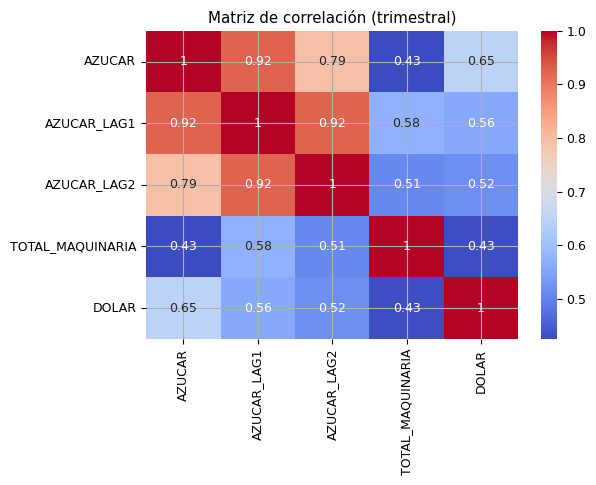


=== COMPARACIÓN MODELOS (AIC/BIC) ===

         Modelo        R2         AIC         BIC
0       Sin Lag  0.181216  910.649313  913.240986
1         Lag 1  0.331285  872.736458  875.252651
2         Lag 2  0.258021  841.800286  844.238037
3   Lag1 + Lag2  0.305783  842.136884  845.793511
4  Lag1 + Dólar  0.354400  873.821840  877.596130


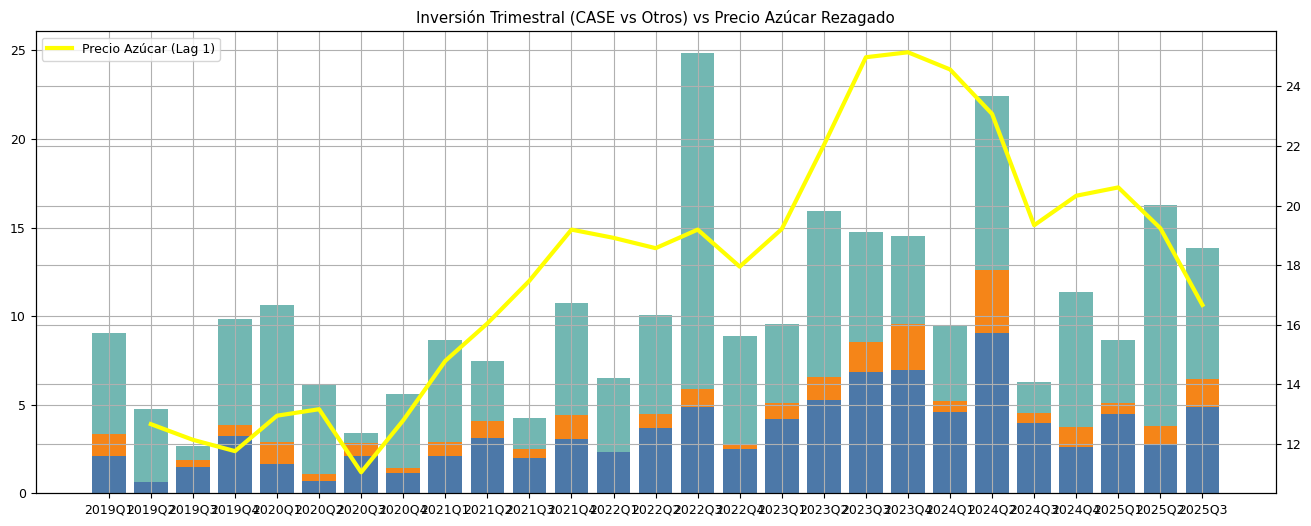

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# ==============================================================
# 1) Cargar y limpiar datos
# ==============================================================

df = pd.read_csv("csv_tractores.csv")

df.columns = df.columns.str.strip().str.upper()
df = df.rename(columns={"DÓLAR": "DOLAR"})  # Normaliza columna

df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# Convertir valores numéricos
for col in df.columns:
    if col != "FECHA":
        df[col] = df[col].astype(str) \
            .str.replace(" ", "", regex=False) \
            .str.replace("$", "", regex=False) \
            .str.replace(",", ".", regex=False)

        df[col] = df[col].replace("-", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==============================================================
# 2) Crear métricas
# ==============================================================

df["TOTAL_TRACTORES"] = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"] = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]

# ==============================================================
# 3) Agregaciones por periodo
# ==============================================================

df["MES"] = df["FECHA"].dt.to_period("M")
df["BIMESTRE"] = df["FECHA"].dt.month.apply(lambda x: (x-1)//2 + 1).astype(str) + "-" + df["FECHA"].dt.year.astype(str)
df["TRIMESTRE"] = df["FECHA"].dt.to_period("Q")
df["CUATRIMESTRE"] = df["FECHA"].dt.month.apply(lambda x: (x-1)//4 + 1).astype(str) + "-" + df["FECHA"].dt.year.astype(str)

def agg(df, col):
    return df.groupby(col).agg({
        "AZUCAR": "mean",
        "DOLAR": "mean",
        "TOTAL_TRACTORES": "sum",
        "TOT_TRACTORES7000_CASE": "sum",
        "TOT_TRACTORES7000": "sum",
        "TOTAL_COSECHADORA": "sum",
        "TOTAL_MAQUINARIA": "sum"
    }).reset_index()

df_mes = agg(df, "MES")
df_bi = agg(df, "BIMESTRE")
df_trim = agg(df, "TRIMESTRE")
df_cuat = agg(df, "CUATRIMESTRE")

# ==============================================================
# 4) Crear Rezagos
# ==============================================================

df_trim["AZUCAR_LAG1"] = df_trim["AZUCAR"].shift(1)
df_trim["AZUCAR_LAG2"] = df_trim["AZUCAR"].shift(2)

# ==============================================================
# 5) Correlaciones
# ==============================================================

corr = df_trim[["AZUCAR", "AZUCAR_LAG1", "AZUCAR_LAG2", "TOTAL_MAQUINARIA", "DOLAR"]].corr()
print("\n=== MATRIZ DE CORRELACIÓN (Trimestral) ===\n")
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (trimestral)")
plt.show()

# ==============================================================
# 6) MODELOS ESTADÍSTICOS
# ==============================================================

def run_model(df, predictors, label):
    data = df.dropna(subset=["TOTAL_MAQUINARIA"] + predictors)
    X = sm.add_constant(data[predictors])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y, X).fit()
    return model, label

m0, label0 = run_model(df_trim, ["AZUCAR"], "Sin Lag")
m1, label1 = run_model(df_trim, ["AZUCAR_LAG1"], "Lag 1")
m2, label2 = run_model(df_trim, ["AZUCAR_LAG2"], "Lag 2")
m3, label3 = run_model(df_trim, ["AZUCAR_LAG1", "AZUCAR_LAG2"], "Lag1 + Lag2")
m4, label4 = run_model(df_trim, ["AZUCAR_LAG1", "DOLAR"], "Lag1 + Dólar")

results = pd.DataFrame({
    "Modelo": [label0, label1, label2, label3, label4],
    "R2": [m0.rsquared, m1.rsquared, m2.rsquared, m3.rsquared, m4.rsquared],
    "AIC": [m0.aic, m1.aic, m2.aic, m3.aic, m4.aic],
    "BIC": [m0.bic, m1.bic, m2.bic, m3.bic, m4.bic]
})

print("\n=== COMPARACIÓN MODELOS (AIC/BIC) ===\n")
print(results)

# ==============================================================
# 7) MEJOR GRÁFICO (Lag1 + CASE vs Otros)
# ==============================================================

plt.figure(figsize=(16,6))
# Tractores otros
plt.bar(df_trim["TRIMESTRE"].astype(str), df_trim["TOT_TRACTORES7000"]/1e6, label="Tractores Otros (MM COP)", color="#4C78A8")
# Tractores CASE
plt.bar(df_trim["TRIMESTRE"].astype(str), df_trim["TOT_TRACTORES7000_CASE"]/1e6,
        bottom=df_trim["TOT_TRACTORES7000"]/1e6,
        label="Tractores CASE (MM COP)", color="#F58518")
# Cosechadoras (total)
plt.bar(df_trim["TRIMESTRE"].astype(str),
        df_trim["TOTAL_COSECHADORA"]/1e6,
        bottom=(df_trim["TOT_TRACTORES7000"]/1e6 + df_trim["TOT_TRACTORES7000_CASE"]/1e6),
        label="Cosechadoras (MM COP)", color="#72B7B2")

ax2 = plt.twinx()
ax2.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR_LAG1"],
         linewidth=3, color="yellow", label="Precio Azúcar (Lag 1)")

plt.title("Inversión Trimestral (CASE vs Otros) vs Precio Azúcar Rezagado")
plt.xticks(rotation=90)
plt.grid(True)
plt.legend(loc="upper left")
plt.show()


In [17]:
# ================================
# SECCIÓN — LIBRERÍAS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

In [18]:
# ================================
#  SECCIÓN 1 — CARGA Y LIMPIEZA
# ================================

file_path = "csv_tractores.csv"   # Cambia si está en otra ruta

df = pd.read_csv(file_path, encoding="latin-1")

# Normalizar nombres
df.columns = df.columns.str.strip().str.upper()

# Corregir columna dólar con acento si existe
if "DÓLAR" in df.columns:
    df = df.rename(columns={"DÓLAR": "DOLAR"})

# Convertir fecha
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# Limpieza de números
for col in df.columns:
    if col != "FECHA":
        df[col] = (
            df[col].astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .replace("-", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")


In [19]:
# ================================
# SECCIÓN 2 — COLUMNAS DERIVADAS
# ================================

df["TOTAL_TRACTORES"] = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"] = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]

# Frecuencias temporales
df["TRIMESTRE"]   = df["FECHA"].dt.to_period("Q")
df["BIMESTRE"]    = df["FECHA"].dt.to_period("2M")
df["CUATRIMESTRE"]= df["FECHA"].dt.to_period("4M")

In [20]:
# ================================
# SECCIÓN 3 — AGREGACIONES
# ================================

# Mensual
df_mes = df.groupby(df["FECHA"].dt.to_period("M")).mean(numeric_only=True)

# Bimestral
df_bi = df.groupby("BIMESTRE").mean(numeric_only=True)

# Trimestral
df_trim = df.groupby("TRIMESTRE").agg({
    "AZUCAR": "mean",
    "DOLAR": "mean",
    "TOTAL_TRACTORES": "sum",
    "TOT_TRACTORES7000_CASE": "sum",
    "TOT_TRACTORES7000": "sum",
    "TOTAL_COSECHADORA": "sum",
    "TOTAL_MAQUINARIA": "sum"
})

# Cuatrimestral
df_cuat = df.groupby("CUATRIMESTRE").mean(numeric_only=True)


In [21]:
# ================================
# SECCIÓN 4 — REZAGOS
# ================================

df_trim["AZUCAR_LAG1"] = df_trim["AZUCAR"].shift(1)
df_trim["AZUCAR_LAG2"] = df_trim["AZUCAR"].shift(2)



🔎 MATRIZ DE CORRELACIÓN TRIMESTRAL:

                    AZUCAR  AZUCAR_LAG1  AZUCAR_LAG2  TOTAL_MAQUINARIA  \
AZUCAR            1.000000     0.924538     0.792315          0.425695   
AZUCAR_LAG1       0.924538     1.000000     0.924456          0.575574   
AZUCAR_LAG2       0.792315     0.924456     1.000000          0.507958   
TOTAL_MAQUINARIA  0.425695     0.575574     0.507958          1.000000   
DOLAR             0.649657     0.559925     0.516653          0.429091   

                     DOLAR  
AZUCAR            0.649657  
AZUCAR_LAG1       0.559925  
AZUCAR_LAG2       0.516653  
TOTAL_MAQUINARIA  0.429091  
DOLAR             1.000000  


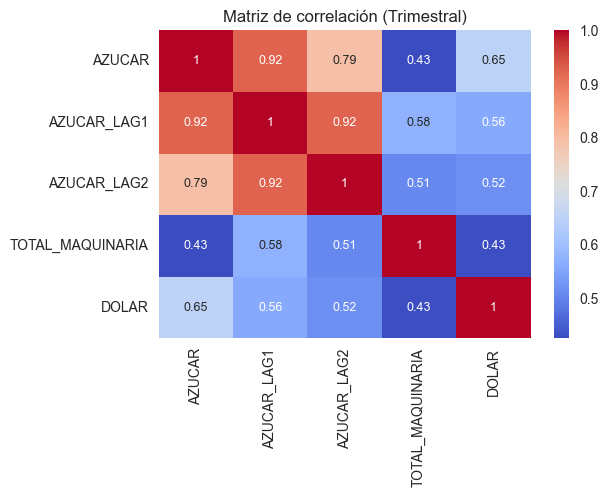

In [22]:
# ================================
# SECCIÓN 5 — CORRELACIONES
# ================================

corr_trim = df_trim[["AZUCAR","AZUCAR_LAG1","AZUCAR_LAG2","TOTAL_MAQUINARIA","DOLAR"]].corr()
print("\n🔎 MATRIZ DE CORRELACIÓN TRIMESTRAL:\n")
print(corr_trim)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_trim, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación (Trimestral)")
plt.show()


In [23]:
# ================================
#  SECCIÓN 6 — REGRESIONES
# ================================

def correr_modelo(df, variables, nombre):
    data = df.dropna(subset=variables + ["TOTAL_MAQUINARIA"])
    X = sm.add_constant(data[variables])
    y = data["TOTAL_MAQUINARIA"]
    model = sm.OLS(y, X).fit()
    return {
        "Modelo": nombre,
        "Vars": variables,
        "R2": model.rsquared,
        "AIC": model.aic,
        "BIC": model.bic,
        "Params": model.params,
        "Pvalues": model.pvalues,
        "Summary": model.summary()
    }

In [24]:
m0 = correr_modelo(df_trim, ["AZUCAR"], "M0: Sin Lag")
m1 = correr_modelo(df_trim, ["AZUCAR_LAG1"], "M1: Lag1")
m2 = correr_modelo(df_trim, ["AZUCAR_LAG2"], "M2: Lag2")
m3 = correr_modelo(df_trim, ["AZUCAR_LAG1","AZUCAR_LAG2"], "M3: Lag1 + Lag2")
m4 = correr_modelo(df_trim, ["AZUCAR_LAG1","DOLAR"], "M4: Lag1 + Dolar")

In [26]:
tabla_modelos = pd.DataFrame([
    {"Modelo": m["Modelo"], "R2": m["R2"], "AIC": m["AIC"], "BIC": m["BIC"], "Variables": m["Vars"]}
    for m in [m0,m1,m2,m3,m4]
]).sort_values("AIC")

print("\nTABLA DE COMPARACIÓN DE MODELOS:\n")
print(tabla_modelos)



TABLA DE COMPARACIÓN DE MODELOS:

             Modelo        R2         AIC         BIC  \
2          M2: Lag2  0.258021  841.800286  844.238037   
3   M3: Lag1 + Lag2  0.305783  842.136884  845.793511   
1          M1: Lag1  0.331285  872.736458  875.252651   
4  M4: Lag1 + Dolar  0.354400  873.821840  877.596130   
0       M0: Sin Lag  0.181216  910.649313  913.240986   

                    Variables  
2               [AZUCAR_LAG2]  
3  [AZUCAR_LAG1, AZUCAR_LAG2]  
1               [AZUCAR_LAG1]  
4        [AZUCAR_LAG1, DOLAR]  
0                    [AZUCAR]  


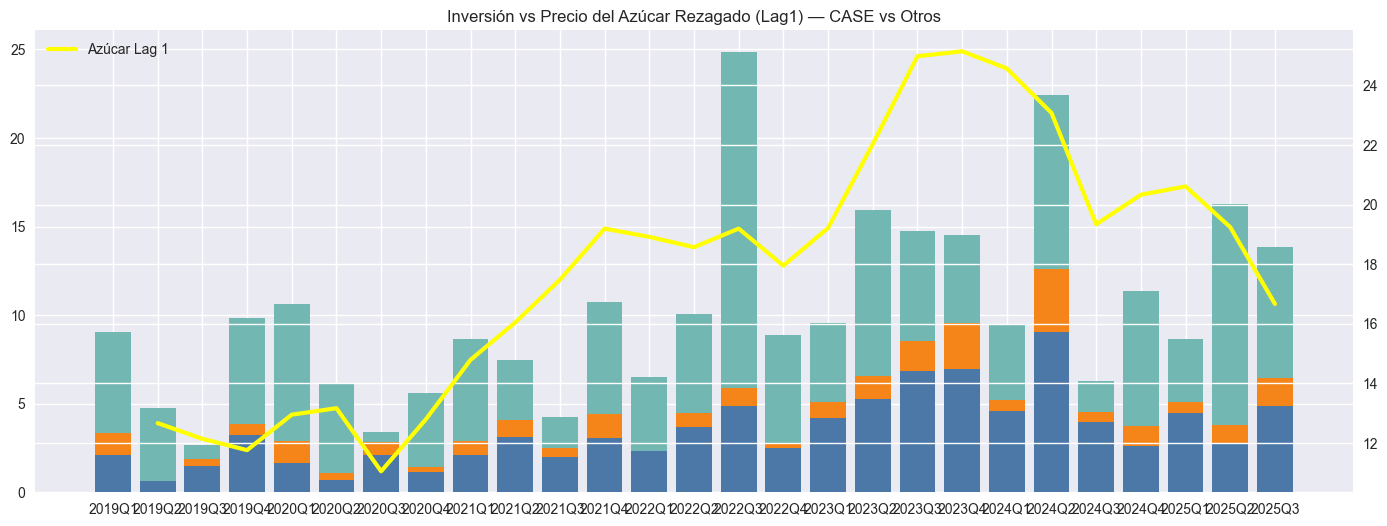

In [27]:
# ================================
#  SECCIÓN 7 — MEJOR GRÁFICO (Lag1 + CASE)
# ================================

plt.figure(figsize=(17,6))

# Tractores Otros
plt.bar(df_trim.index.astype(str), df_trim["TOT_TRACTORES7000"]/1e6, label="Tractores Otros", color="#4C78A8")

# Tractores CASE
plt.bar(df_trim.index.astype(str), df_trim["TOT_TRACTORES7000_CASE"]/1e6,
        bottom=df_trim["TOT_TRACTORES7000"]/1e6, label="Tractores CASE", color="#F58518")

# Cosechadoras
plt.bar(df_trim.index.astype(str), df_trim["TOTAL_COSECHADORA"]/1e6,
        bottom=(df_trim["TOT_TRACTORES7000"]/1e6 + df_trim["TOT_TRACTORES7000_CASE"]/1e6),
        label="Cosechadoras", color="#72B7B2")

# Línea de azúcar lag1
ax2 = plt.twinx()
ax2.plot(df_trim.index.astype(str), df_trim["AZUCAR_LAG1"], color="yellow", linewidth=3, label="Azúcar Lag 1")

plt.title("Inversión vs Precio del Azúcar Rezagado (Lag1) — CASE vs Otros")
plt.xticks(rotation=90)
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


Primeras filas después de limpieza:
        FECHA    DOLAR  AZUCAR  TOT_COSECHADORA  TOT_COSECHA_CASE  \
0 2019-01-01  3103.25   12.73       1702863.63        1702863.63   
1 2019-02-01  3080.25   12.73              NaN               NaN   
2 2019-03-01  3186.03   12.53       1148713.83        1148713.83   
3 2019-04-01  3231.25   11.99       1174704.15        1174704.15   
4 2019-05-01  3375.00   12.10              NaN               NaN   

   TOT_TRACTORES7000  TOT_TRACTORES7000_CASE  SUMA_TRACTOR_COSECHADORA  
0          239755.20               133465.73                1942618.83  
1          684983.60               439023.27                 684983.60  
2         1175085.83               693708.90                2323799.66  
3          130220.75                     NaN                1304924.90  
4          181115.61                     NaN                 181115.61   

Resumen por frecuencia (primeras filas trimestrales):
   TRIMESTRE     AZUCAR        DOLAR  TOTAL_TRACTORES  TOTAL

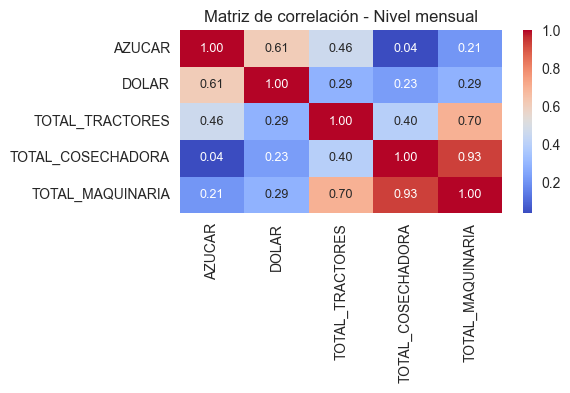

Correlación AZUCAR vs TOTAL_MAQUINARIA por frecuencia:
       Frecuencia  Correlacion
0        Mensual        0.212
1      Bimestral        0.212
2     Trimestral        0.426
3  Cuatrimestral        0.212 

Modelos OLS por frecuencia (TOTAL_MAQUINARIA ~ AZUCAR):
       Frecuencia  N_periodos      R2  Coef_Azucar  P_Azucar
0        Mensual          80  0.0451  141016.2827    0.0586
1      Bimestral          80  0.0451  141016.2827    0.0586
2     Trimestral          27  0.1812  545875.8227    0.0268
3  Cuatrimestral          80  0.0451  141016.2827    0.0586 

Comparación de modelos con rezagos (Trimestral):
              Modelo                 Variables  N_obs      R2       AIC  \
2         M2: Lag 2               AZUCAR_LAG2     25  0.2580  841.8003   
3   M3: Lag1 + Lag2  AZUCAR_LAG1, AZUCAR_LAG2     25  0.3058  842.1369   
1         M1: Lag 1               AZUCAR_LAG1     26  0.3313  872.7365   
4  M4: Lag1 + DOLAR        AZUCAR_LAG1, DOLAR     26  0.3544  873.8218   
0       M0: S

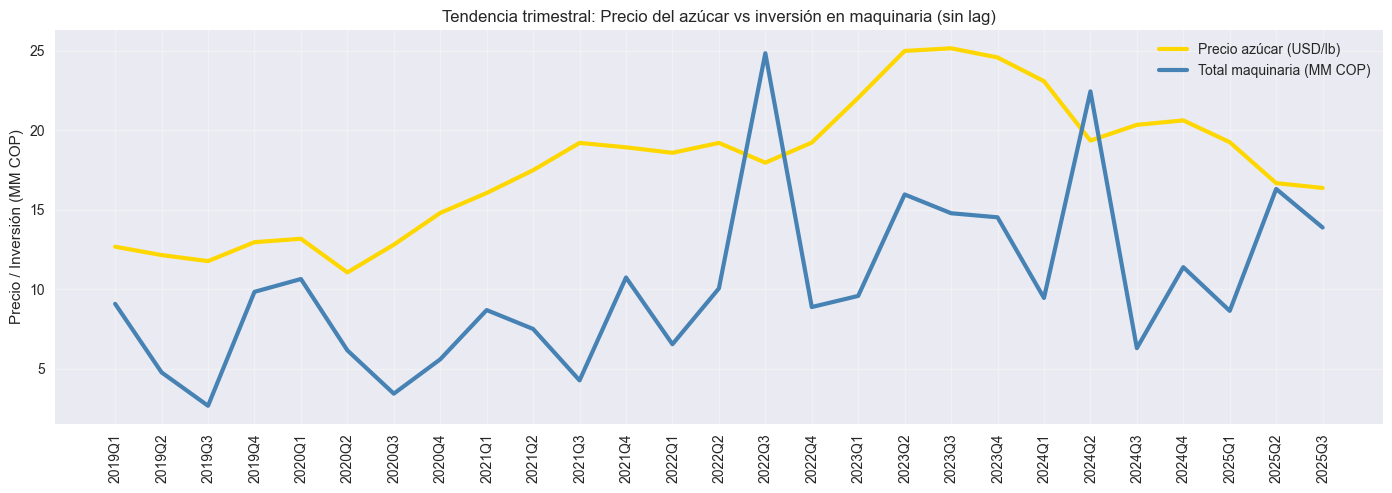

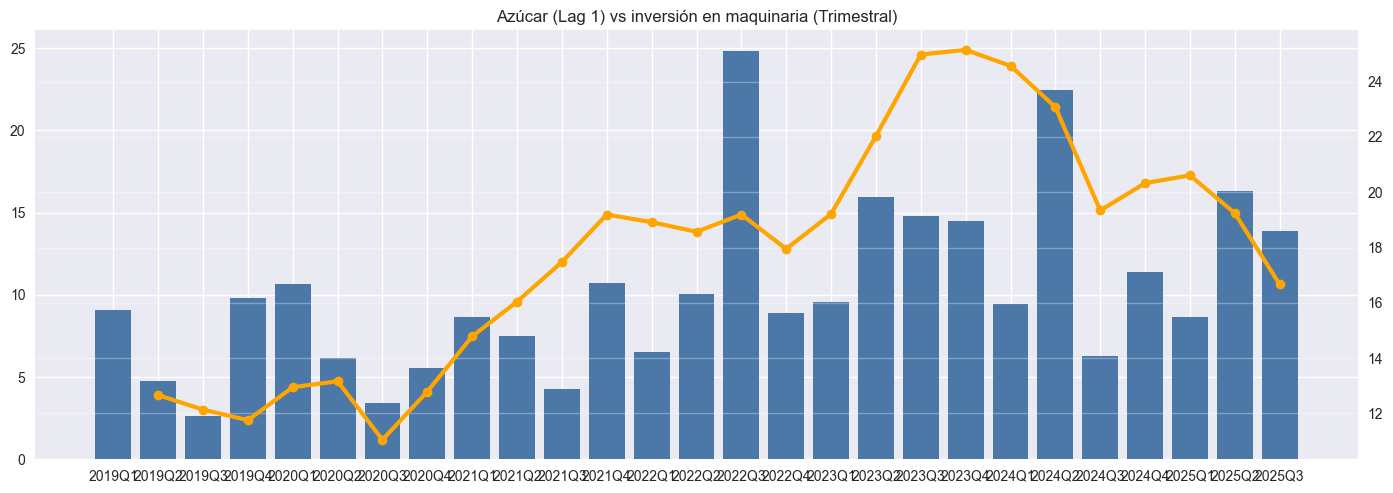

C:\Users\andres.hernandez\AppData\Local\Temp\ipykernel_39232\1405493124.py:287: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x, rotation=90)


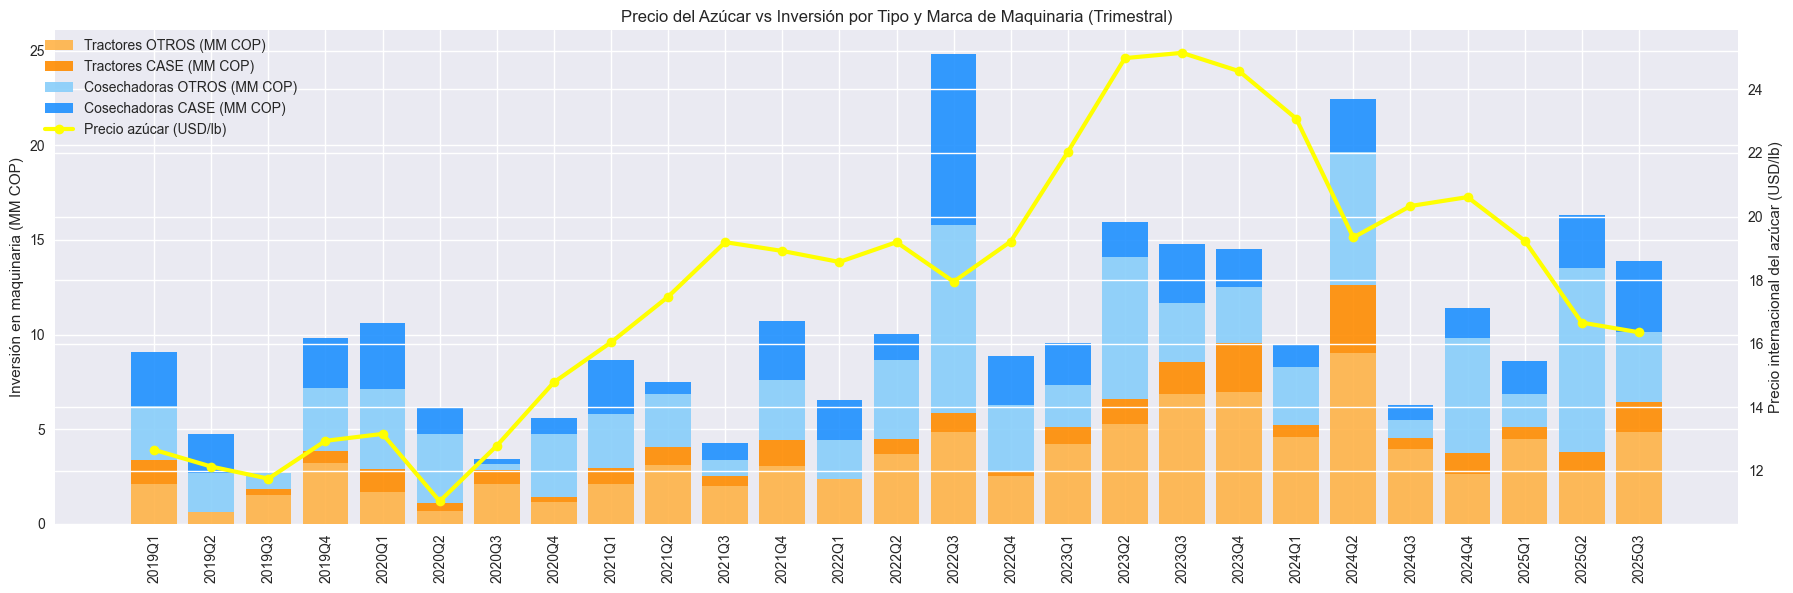


================= CONCLUSIÓN EJECUTIVA (RESUMEN) =================

- El análisis por frecuencia muestra que el modelo trimestral TOTAL_MAQUINARIA ~ AZUCAR
  es el único con significancia clara (R2 ~ 0.181).

- Los modelos con rezagos evidencian que AZUCAR_LAG1 (azúcar del trimestre anterior)
  mejora sensiblemente el ajuste (R2 y AIC), siendo el mejor modelo: M2: Lag 2.

- Los gráficos apilados por tipo y marca confirman visualmente que los picos de inversión
  en tractores y cosechadoras (especialmente CASE) coinciden con periodos de precios altos
  del azúcar, validando la hipótesis de un CAPEX ligado al ciclo de rentabilidad del sector.



In [28]:
# ============================================================
# ANALISIS COMPLETO: AZÚCAR vs VENTAS DE MAQUINARIA (TRACTORES + COSECHADORAS)
# Incluye:
#   - Limpieza del CSV
#   - Agregaciones: mensual, bimestral, trimestral, cuatrimestral
#   - Correlaciones
#   - Modelos OLS (sin lag y con lag)
#   - Comparación de modelos (R2, AIC, BIC)
#   - Gráficos: totales y discriminación CASE vs otros (tractores y cosechadoras)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")

# ============================================================
# 1) CARGA Y LIMPIEZA DEL CSV
# ============================================================

FILE_PATH = "csv_tractores.csv"   # <-- ajusta si tu archivo tiene otro nombre o ruta

# El archivo viene en latin-1 por el carácter "Ó" en "DÓLAR"
df = pd.read_csv(FILE_PATH, encoding="latin-1")

# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.upper()

# Renombrar DÓLAR a DOLAR si existe
if "DÓLAR" in df.columns:
    df = df.rename(columns={"DÓLAR": "DOLAR"})

# Convertir FECHA a datetime (formato DD/MM/YYYY)
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# Limpiar columnas numéricas
for col in df.columns:
    if col != "FECHA":
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .replace("-", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Primeras filas después de limpieza:\n", df.head(), "\n")

# ============================================================
# 2) COLUMNAS DERIVADAS (TOTALES Y MARCAS)
# ============================================================

# Totales por tipo
df["TOTAL_TRACTORES"]   = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"]  = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]

# Detalle por marca y tipo
df["TRACTORES_OTROS"]      = df["TOT_TRACTORES7000"].fillna(0)
df["TRACTORES_CASE"]       = df["TOT_TRACTORES7000_CASE"].fillna(0)
df["COSECHADORAS_OTROS"]   = df["TOT_COSECHADORA"].fillna(0)
df["COSECHADORAS_CASE"]    = df["TOT_COSECHA_CASE"].fillna(0)

# Frecuencias de tiempo
df["MES"]          = df["FECHA"].dt.to_period("M")
df["BIMESTRE"]     = df["FECHA"].dt.to_period("2M")
df["TRIMESTRE"]    = df["FECHA"].dt.to_period("Q")
df["CUATRIMESTRE"] = df["FECHA"].dt.to_period("4M")

# ============================================================
# 3) FUNCIONES DE AGREGACIÓN POR PERIODO
# ============================================================

def agrupar_por(df_base, columna_periodo):
    """
    Agrupa por un periodo de tiempo y calcula:
    - Promedio de AZUCAR y DOLAR
    - Suma de montos de maquinaria
    """
    return df_base.groupby(columna_periodo).agg({
        "AZUCAR": "mean",
        "DOLAR": "mean",
        "TOTAL_TRACTORES": "sum",
        "TOTAL_COSECHADORA": "sum",
        "TOTAL_MAQUINARIA": "sum"
    }).reset_index()

df_mes  = agrupar_por(df, "MES")
df_bi   = agrupar_por(df, "BIMESTRE")
df_trim = agrupar_por(df, "TRIMESTRE")
df_cuat = agrupar_por(df, "CUATRIMESTRE")

print("Resumen por frecuencia (primeras filas trimestrales):\n", df_trim.head(), "\n")

# ============================================================
# 4) CORRELACIONES (MENSUAL Y TRIMESTRAL)
# ============================================================

# Correlación mensual
corr_mes = df_mes[["AZUCAR","DOLAR","TOTAL_TRACTORES","TOTAL_COSECHADORA","TOTAL_MAQUINARIA"]].corr()
print("Matriz de correlación mensual:\n", corr_mes.round(3), "\n")

plt.figure(figsize=(6,4))
sns.heatmap(corr_mes, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación - Nivel mensual")
plt.tight_layout()
plt.show()

# Correlación AZUCAR vs TOTAL_MAQUINARIA por frecuencia
def corr_azucar_maquinaria(df_agg, label):
    c = df_agg[["AZUCAR","TOTAL_MAQUINARIA"]].corr().iloc[0,1]
    return {"Frecuencia": label, "Correlacion": c}

corr_tab = pd.DataFrame([
    corr_azucar_maquinaria(df_mes,  "Mensual"),
    corr_azucar_maquinaria(df_bi,   "Bimestral"),
    corr_azucar_maquinaria(df_trim, "Trimestral"),
    corr_azucar_maquinaria(df_cuat, "Cuatrimestral"),
])

print("Correlación AZUCAR vs TOTAL_MAQUINARIA por frecuencia:\n", corr_tab.round(3), "\n")

# ============================================================
# 5) MODELOS OLS POR FRECUENCIA (SIN LAG)
# ============================================================

def modelo_simple(df_agg, label):
    datos = df_agg[["TOTAL_MAQUINARIA","AZUCAR"]].dropna()
    X = sm.add_constant(datos["AZUCAR"])
    y = datos["TOTAL_MAQUINARIA"]
    m = sm.OLS(y, X).fit()
    return {
        "Frecuencia": label,
        "N_periodos": len(datos),
        "R2": m.rsquared,
        "Coef_Azucar": m.params["AZUCAR"],
        "P_Azucar": m.pvalues["AZUCAR"]
    }

tabla_freq = pd.DataFrame([
    modelo_simple(df_mes,  "Mensual"),
    modelo_simple(df_bi,   "Bimestral"),
    modelo_simple(df_trim, "Trimestral"),
    modelo_simple(df_cuat, "Cuatrimestral")
])

print("Modelos OLS por frecuencia (TOTAL_MAQUINARIA ~ AZUCAR):\n", tabla_freq.round(4), "\n")

# ============================================================
# 6) REZAGOS TRIMESTRALES (LAG1, LAG2) Y MODELOS
# ============================================================

df_trim_lag = df_trim.copy()
df_trim_lag["AZUCAR_LAG1"] = df_trim_lag["AZUCAR"].shift(1)
df_trim_lag["AZUCAR_LAG2"] = df_trim_lag["AZUCAR"].shift(2)

def correr_modelo(df_lag, variables, nombre):
    datos = df_lag[["TOTAL_MAQUINARIA"] + variables].dropna()
    X = sm.add_constant(datos[variables])
    y = datos["TOTAL_MAQUINARIA"]
    modelo = sm.OLS(y, X).fit()
    return {
        "Modelo": nombre,
        "Variables": variables,
        "N": len(datos),
        "R2": modelo.rsquared,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "Params": modelo.params,
        "Pvalues": modelo.pvalues,
        "Summary": modelo
    }

m0 = correr_modelo(df_trim_lag, ["AZUCAR"],                  "M0: Sin lag")
m1 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1"],            "M1: Lag 1")
m2 = correr_modelo(df_trim_lag, ["AZUCAR_LAG2"],            "M2: Lag 2")
m3 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1","AZUCAR_LAG2"], "M3: Lag1 + Lag2")
m4 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1","DOLAR"],    "M4: Lag1 + DOLAR")

tabla_modelos = pd.DataFrame([
    {
        "Modelo": m["Modelo"],
        "Variables": ", ".join(m["Variables"]),
        "N_obs": m["N"],
        "R2": m["R2"],
        "AIC": m["AIC"],
        "BIC": m["BIC"]
    }
    for m in [m0,m1,m2,m3,m4]
]).sort_values("AIC")

print("Comparación de modelos con rezagos (Trimestral):\n", tabla_modelos.round(4), "\n")

# Opcional: ver resumen completo del mejor modelo (probablemente M1 o M4)
print("Resumen del mejor modelo según AIC (fila 0):\n")
best_name = tabla_modelos.iloc[0]["Modelo"]
best_model = {"M0: Sin lag": m0, "M1: Lag 1": m1, "M2: Lag 2": m2,
              "M3: Lag1 + Lag2": m3, "M4: Lag1 + DOLAR": m4}[best_name]
print(best_model["Summary"].summary())

# ============================================================
# 7) GRÁFICOS PRINCIPALES
# ============================================================

# 7.1 Tendencia trimestral sin lag (Total maquinaria vs azúcar)
plt.figure(figsize=(14,5))
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR"],
         label="Precio azúcar (USD/lb)", linewidth=3, color="gold")
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_MAQUINARIA"]/1e6,
         label="Total maquinaria (MM COP)", linewidth=3, color="steelblue")
plt.title("Tendencia trimestral: Precio del azúcar vs inversión en maquinaria (sin lag)")
plt.xticks(rotation=90)
plt.ylabel("Precio / Inversión (MM COP)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7.2 Lag1: barras de maquinaria + línea azúcar rezagado
plt.figure(figsize=(14,5))
plt.bar(df_trim_lag["TRIMESTRE"].astype(str),
        df_trim_lag["TOTAL_MAQUINARIA"]/1e6,
        label="Total maquinaria (MM COP)",
        color="#4C78A8")
ax2 = plt.twinx()
ax2.plot(df_trim_lag["TRIMESTRE"].astype(str),
         df_trim_lag["AZUCAR_LAG1"],
         label="Azúcar (Lag 1 trimestre)",
         color="orange", linewidth=3, marker="o")
plt.title("Azúcar (Lag 1) vs inversión en maquinaria (Trimestral)")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 8) GRÁFICO COMPLETO: CASE vs OTROS + AZÚCAR (SIN LAG)
# ============================================================

# Reagregar detallado por marca y tipo
df_trim_det = df.groupby("TRIMESTRE").agg({
    "AZUCAR": "mean",
    "TRACTORES_OTROS": "sum",
    "TRACTORES_CASE": "sum",
    "COSECHADORAS_OTROS": "sum",
    "COSECHADORAS_CASE": "sum"
}).reset_index()

x = df_trim_det["TRIMESTRE"].astype(str)

fig, ax1 = plt.subplots(figsize=(18,6))

# Tractores Otros
ax1.bar(x,
        df_trim_det["TRACTORES_OTROS"]/1e6,
        label="Tractores OTROS (MM COP)",
        color="#ffb347", alpha=0.9)

# Tractores CASE
ax1.bar(x,
        df_trim_det["TRACTORES_CASE"]/1e6,
        bottom=df_trim_det["TRACTORES_OTROS"]/1e6,
        label="Tractores CASE (MM COP)",
        color="#ff8c00", alpha=0.9)

# Cosechadoras Otros
ax1.bar(x,
        df_trim_det["COSECHADORAS_OTROS"]/1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"] + df_trim_det["TRACTORES_CASE"])/1e6,
        label="Cosechadoras OTROS (MM COP)",
        color="#87CEFA", alpha=0.9)

# Cosechadoras CASE
ax1.bar(x,
        df_trim_det["COSECHADORAS_CASE"]/1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"] + df_trim_det["TRACTORES_CASE"]
                + df_trim_det["COSECHADORAS_OTROS"])/1e6,
        label="Cosechadoras CASE (MM COP)",
        color="#1E90FF", alpha=0.9)

ax1.set_ylabel("Inversión en maquinaria (MM COP)")
ax1.set_xticklabels(x, rotation=90)

# Línea de azúcar (sin lag)
ax2 = ax1.twinx()
ax2.plot(x, df_trim_det["AZUCAR"],
         color="yellow", linewidth=3, marker="o",
         label="Precio azúcar (USD/lb)")
ax2.set_ylabel("Precio internacional del azúcar (USD/lb)")

fig.legend(loc="upper left", bbox_to_anchor=(0.02, 0.95))
plt.title("Precio del Azúcar vs Inversión por Tipo y Marca de Maquinaria (Trimestral)")
plt.tight_layout()
plt.show()

# ============================================================
# 9) MENSAJE RESUMEN EN CONSOLA
# ============================================================

print("\n================= CONCLUSIÓN EJECUTIVA (RESUMEN) =================\n")
print(
    "- El análisis por frecuencia muestra que el modelo trimestral TOTAL_MAQUINARIA ~ AZUCAR\n"
    f"  es el único con significancia clara (R2 ~ {tabla_freq.loc[tabla_freq['Frecuencia']=='Trimestral','R2'].values[0]:.3f}).\n\n"
    "- Los modelos con rezagos evidencian que AZUCAR_LAG1 (azúcar del trimestre anterior)\n"
    f"  mejora sensiblemente el ajuste (R2 y AIC), siendo el mejor modelo: {best_name}.\n\n"
    "- Los gráficos apilados por tipo y marca confirman visualmente que los picos de inversión\n"
    "  en tractores y cosechadoras (especialmente CASE) coinciden con periodos de precios altos\n"
    "  del azúcar, validando la hipótesis de un CAPEX ligado al ciclo de rentabilidad del sector.\n"
)


In [29]:
# ============================================================
# PARTE 0: LIBRERÍAS Y ESTILO
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


HEAD LIMPIO:
        FECHA    DOLAR  AZUCAR  TOT_COSECHADORA  TOT_COSECHA_CASE  \
0 2019-01-01 3,103.25   12.73     1,702,863.63      1,702,863.63   
1 2019-02-01 3,080.25   12.73              NaN               NaN   
2 2019-03-01 3,186.03   12.53     1,148,713.83      1,148,713.83   
3 2019-04-01 3,231.25   11.99     1,174,704.15      1,174,704.15   
4 2019-05-01 3,375.00   12.10              NaN               NaN   

   TOT_TRACTORES7000  TOT_TRACTORES7000_CASE  SUMA_TRACTOR_COSECHADORA  \
0         239,755.20              133,465.73              1,942,618.83   
1         684,983.60              439,023.27                684,983.60   
2       1,175,085.83              693,708.90              2,323,799.66   
3         130,220.75                     NaN              1,304,924.90   
4         181,115.61                     NaN                181,115.61   

   TOTAL_TRACTORES  TOTAL_COSECHADORA  TOTAL_MAQUINARIA  TRACTORES_OTROS  \
0       373,220.93       3,405,727.26      3,778,948.19 

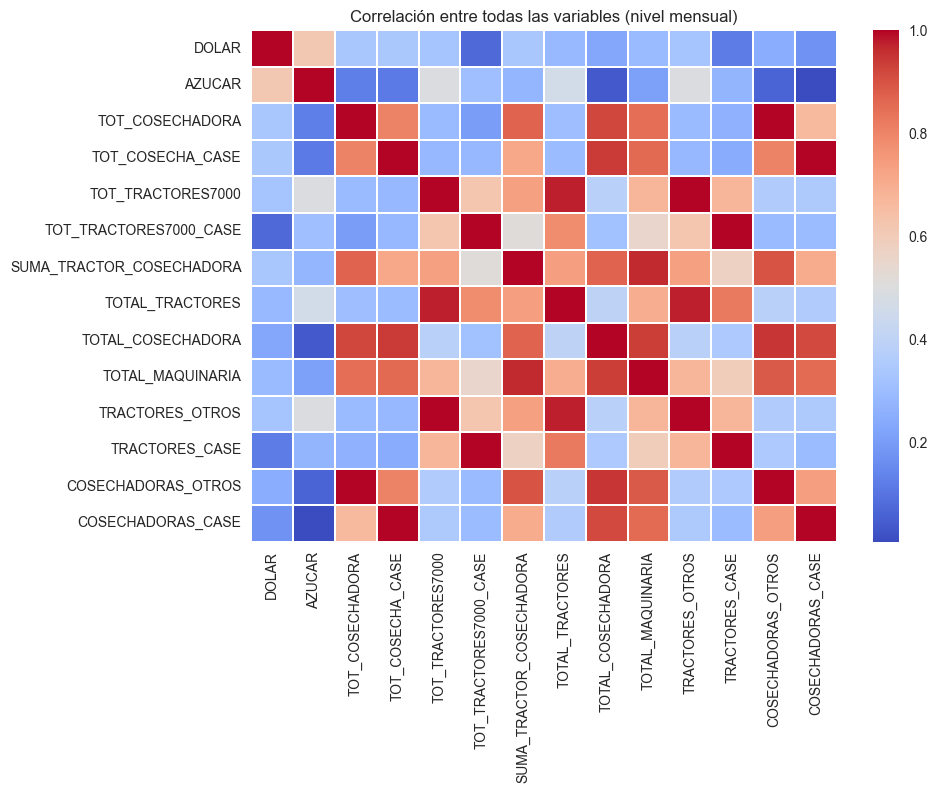

In [31]:
# ============================================================
# PARTE 1: CARGA, LIMPIEZA Y CORRELACIÓN GENERAL (MENSUAL)
# ============================================================

FILE_PATH = "csv_tractores.csv"   # <- ajusta si tu archivo tiene otra ruta

# 1.1 Cargar con codificación latin-1 (por la ó de DÓLAR)
df = pd.read_csv(FILE_PATH, encoding="latin-1")

# 1.2 Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.upper()
if "DÓLAR" in df.columns:
    df = df.rename(columns={"DÓLAR": "DOLAR"})

# 1.3 Convertir FECHA
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

# 1.4 Limpiar numéricos (quita $, espacios, usa punto decimal, "-" -> NaN)
for col in df.columns:
    if col != "FECHA":
        df[col] = (
            df[col].astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .replace("-", np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 1.5 Crear totales y desagregaciones
df["TOTAL_TRACTORES"]   = df["TOT_TRACTORES7000"].fillna(0) + df["TOT_TRACTORES7000_CASE"].fillna(0)
df["TOTAL_COSECHADORA"] = df["TOT_COSECHADORA"].fillna(0) + df["TOT_COSECHA_CASE"].fillna(0)
df["TOTAL_MAQUINARIA"]  = df["TOTAL_TRACTORES"] + df["TOTAL_COSECHADORA"]

df["TRACTORES_OTROS"]      = df["TOT_TRACTORES7000"].fillna(0)
df["TRACTORES_CASE"]       = df["TOT_TRACTORES7000_CASE"].fillna(0)
df["COSECHADORAS_OTROS"]   = df["TOT_COSECHADORA"].fillna(0)
df["COSECHADORAS_CASE"]    = df["TOT_COSECHA_CASE"].fillna(0)

print("HEAD LIMPIO:\n", df.head(), "\n")

# 1.6 Matriz de correlación de TODAS las variables numéricas (nivel mensual)
num_cols = df.select_dtypes(include=[np.number])
corr_all = num_cols.corr()

print("MATRIZ DE CORRELACIÓN COMPLETA (MENSUAL):\n")
print(corr_all.round(3))

plt.figure(figsize=(10,8))
sns.heatmap(corr_all, annot=False, cmap="coolwarm", linewidths=0.3)
plt.title("Correlación entre todas las variables (nivel mensual)")
plt.tight_layout()
plt.show()


In [32]:
# ============================================================
# PARTE 2: MODELOS OLS POR FRECUENCIA
#   TOTAL_MAQUINARIA ~ AZUCAR
# ============================================================

# 2.1 Crear periodos
df["MES"]          = df["FECHA"].dt.to_period("M")
df["BIMESTRE"]     = df["FECHA"].dt.to_period("2M")
df["TRIMESTRE"]    = df["FECHA"].dt.to_period("Q")
df["CUATRIMESTRE"] = df["FECHA"].dt.to_period("4M")

def agregar_por(df_base, col_periodo):
    """Agrupa por periodo y calcula promedio de AZUCAR/DOLAR y sumas de montos."""
    return df_base.groupby(col_periodo).agg({
        "AZUCAR": "mean",
        "DOLAR": "mean",
        "TOTAL_TRACTORES": "sum",
        "TOTAL_COSECHADORA": "sum",
        "TOTAL_MAQUINARIA": "sum"
    }).reset_index()

df_mes  = agregar_por(df, "MES")
df_bi   = agregar_por(df, "BIMESTRE")
df_trim = agregar_por(df, "TRIMESTRE")
df_cuat = agregar_por(df, "CUATRIMESTRE")

print("HEAD TRIMESTRAL:\n", df_trim.head(), "\n")

# 2.2 Función para correr modelo simple TOTAL_MAQUINARIA ~ AZUCAR
def modelo_simple(df_agg, label):
    datos = df_agg[["TOTAL_MAQUINARIA","AZUCAR"]].dropna()
    X = sm.add_constant(datos["AZUCAR"])
    y = datos["TOTAL_MAQUINARIA"]
    m = sm.OLS(y, X).fit()
    return {
        "Frecuencia": label,
        "N_periodos": len(datos),
        "R2": m.rsquared,
        "Coef_Azucar": m.params["AZUCAR"],
        "P_Azucar": m.pvalues["AZUCAR"],
        "AIC": m.aic,
        "BIC": m.bic
    }

tabla_freq = pd.DataFrame([
    modelo_simple(df_mes,  "Mensual"),
    modelo_simple(df_bi,   "Bimestral"),
    modelo_simple(df_trim, "Trimestral"),
    modelo_simple(df_cuat, "Cuatrimestral"),
])

print("MODELOS POR FRECUENCIA (TOTAL_MAQUINARIA ~ AZUCAR):\n")
print(tabla_freq.round(4))


HEAD TRIMESTRAL:
   TRIMESTRE  AZUCAR    DOLAR  TOTAL_TRACTORES  TOTAL_COSECHADORA  \
0    2019Q1   12.66 3,123.18     3,366,022.53       5,703,154.92   
1    2019Q2   12.14 3,272.42       636,135.45       4,118,413.86   
2    2019Q3   11.76 3,398.28     1,855,972.77         799,327.16   
3    2019Q4   12.95 3,392.58     3,827,938.91       5,995,139.14   
4    2020Q1   13.16 3,666.33     2,906,662.42       7,724,331.34   

   TOTAL_MAQUINARIA  
0      9,069,177.45  
1      4,754,549.31  
2      2,655,299.93  
3      9,823,078.05  
4     10,630,993.76   

MODELOS POR FRECUENCIA (TOTAL_MAQUINARIA ~ AZUCAR):

      Frecuencia  N_periodos   R2  Coef_Azucar  P_Azucar      AIC      BIC
0        Mensual          80 0.05   141,016.28      0.06 2,603.00 2,607.76
1      Bimestral          80 0.05   141,016.28      0.06 2,603.00 2,607.76
2     Trimestral          27 0.18   545,875.82      0.03   910.65   913.24
3  Cuatrimestral          80 0.05   141,016.28      0.06 2,603.00 2,607.76


CORRELACIÓN AZÚCAR / LAGS vs TOTAL_MAQUINARIA (TRIMESTRAL):

                  AZUCAR  AZUCAR_LAG1  AZUCAR_LAG2  TOTAL_MAQUINARIA  DOLAR
AZUCAR              1.00         0.93         0.79              0.43   0.65
AZUCAR_LAG1         0.93         1.00         0.92              0.58   0.56
AZUCAR_LAG2         0.79         0.92         1.00              0.51   0.52
TOTAL_MAQUINARIA    0.43         0.58         0.51              1.00   0.43
DOLAR               0.65         0.56         0.52              0.43   1.00


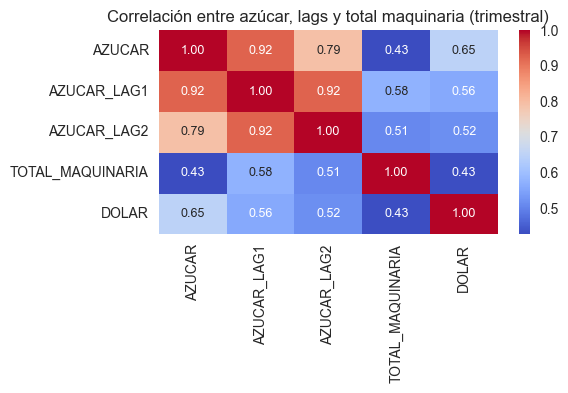

In [33]:
# ============================================================
# PARTE 3: CORRELACIÓN PRECIO vs MAQUINARIA CON LAGS (TRIMESTRAL)
# ============================================================

# 3.1 Crear rezagos sobre la tabla trimestral
df_trim_lag = df_trim.copy()
df_trim_lag["AZUCAR_LAG1"] = df_trim_lag["AZUCAR"].shift(1)
df_trim_lag["AZUCAR_LAG2"] = df_trim_lag["AZUCAR"].shift(2)

# 3.2 Correlación solo entre azúcar (actual y lags) vs TOTAL_MAQUINARIA + DOLAR
corr_lags = df_trim_lag[["AZUCAR","AZUCAR_LAG1","AZUCAR_LAG2","TOTAL_MAQUINARIA","DOLAR"]].corr()

print("CORRELACIÓN AZÚCAR / LAGS vs TOTAL_MAQUINARIA (TRIMESTRAL):\n")
print(corr_lags.round(3))

plt.figure(figsize=(6,4))
sns.heatmap(corr_lags, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre azúcar, lags y total maquinaria (trimestral)")
plt.tight_layout()
plt.show()


In [34]:
# ============================================================
# PARTE 4: MODELOS CON LAGS (TRIMESTRAL)
#   M0: TOTAL ~ AZUCAR
#   M1: TOTAL ~ AZUCAR_LAG1
#   M2: TOTAL ~ AZUCAR_LAG2
#   M3: TOTAL ~ AZUCAR_LAG1 + AZUCAR_LAG2
#   M4: TOTAL ~ AZUCAR_LAG1 + DOLAR
# ============================================================

def correr_modelo(df_lag, variables, nombre):
    datos = df_lag[["TOTAL_MAQUINARIA"] + variables].dropna()
    X = sm.add_constant(datos[variables])
    y = datos["TOTAL_MAQUINARIA"]
    modelo = sm.OLS(y, X).fit()
    return {
        "Modelo": nombre,
        "Variables": ", ".join(variables),
        "N_obs": len(datos),
        "R2": modelo.rsquared,
        "AIC": modelo.aic,
        "BIC": modelo.bic,
        "Summary": modelo
    }

m0 = correr_modelo(df_trim_lag, ["AZUCAR"],                  "M0: Sin lag")
m1 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1"],            "M1: Lag 1")
m2 = correr_modelo(df_trim_lag, ["AZUCAR_LAG2"],            "M2: Lag 2")
m3 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1","AZUCAR_LAG2"], "M3: Lag1 + Lag2")
m4 = correr_modelo(df_trim_lag, ["AZUCAR_LAG1","DOLAR"],    "M4: Lag1 + DOLAR")

tabla_modelos = pd.DataFrame([
    {"Modelo": m["Modelo"], "Variables": m["Variables"], "N_obs": m["N_obs"],
     "R2": m["R2"], "AIC": m["AIC"], "BIC": m["BIC"]}
    for m in [m0,m1,m2,m3,m4]
]).sort_values("AIC")

print("COMPARACIÓN M0–M4 (R2 / AIC / BIC):\n")
print(tabla_modelos.round(4))

# Si quieres el resumen completo del mejor:
mejor_nombre = tabla_modelos.iloc[0]["Modelo"]
mejor_modelo = {"M0: Sin lag": m0, "M1: Lag 1": m1, "M2: Lag 2": m2,
                "M3: Lag1 + Lag2": m3, "M4: Lag1 + DOLAR": m4}[mejor_nombre]

print("\nRESUMEN COMPLETO DEL MEJOR MODELO (", mejor_nombre, "):\n")
print(mejor_modelo["Summary"].summary())


COMPARACIÓN M0–M4 (R2 / AIC / BIC):

             Modelo                 Variables  N_obs   R2    AIC    BIC
2         M2: Lag 2               AZUCAR_LAG2     25 0.26 841.80 844.24
3   M3: Lag1 + Lag2  AZUCAR_LAG1, AZUCAR_LAG2     25 0.31 842.14 845.79
1         M1: Lag 1               AZUCAR_LAG1     26 0.33 872.74 875.25
4  M4: Lag1 + DOLAR        AZUCAR_LAG1, DOLAR     26 0.35 873.82 877.60
0       M0: Sin lag                    AZUCAR     27 0.18 910.65 913.24

RESUMEN COMPLETO DEL MEJOR MODELO ( M2: Lag 2 ):

                            OLS Regression Results                            
Dep. Variable:       TOTAL_MAQUINARIA   R-squared:                       0.258
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     7.998
Date:                Thu, 20 Nov 2025   Prob (F-statistic):            0.00953
Time:                        23:00:15   Log-Likelihood:                -418.90
No. Ob

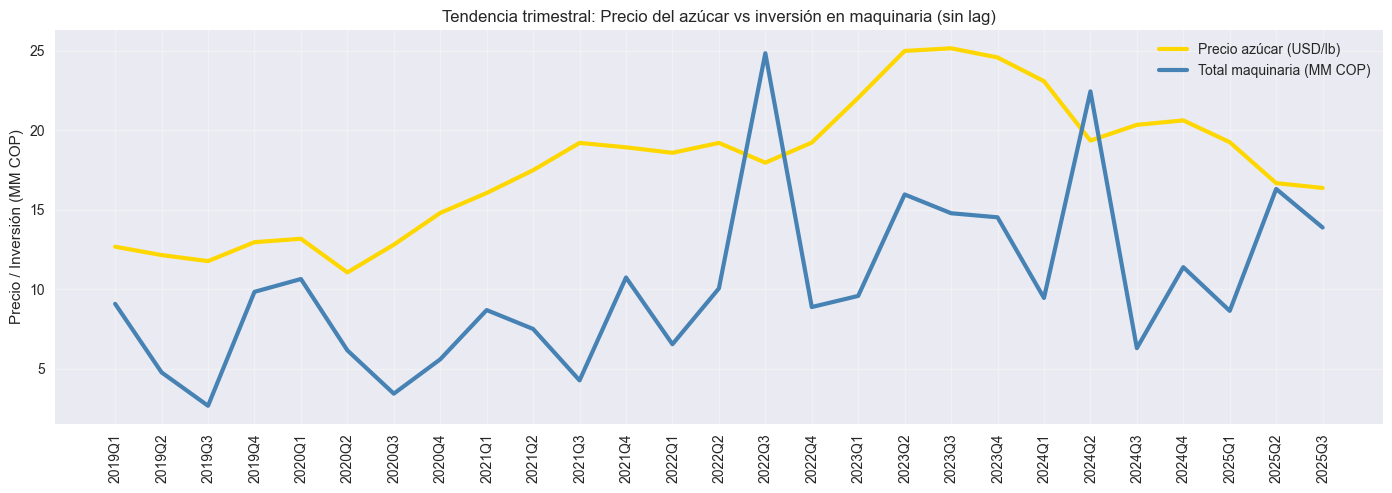

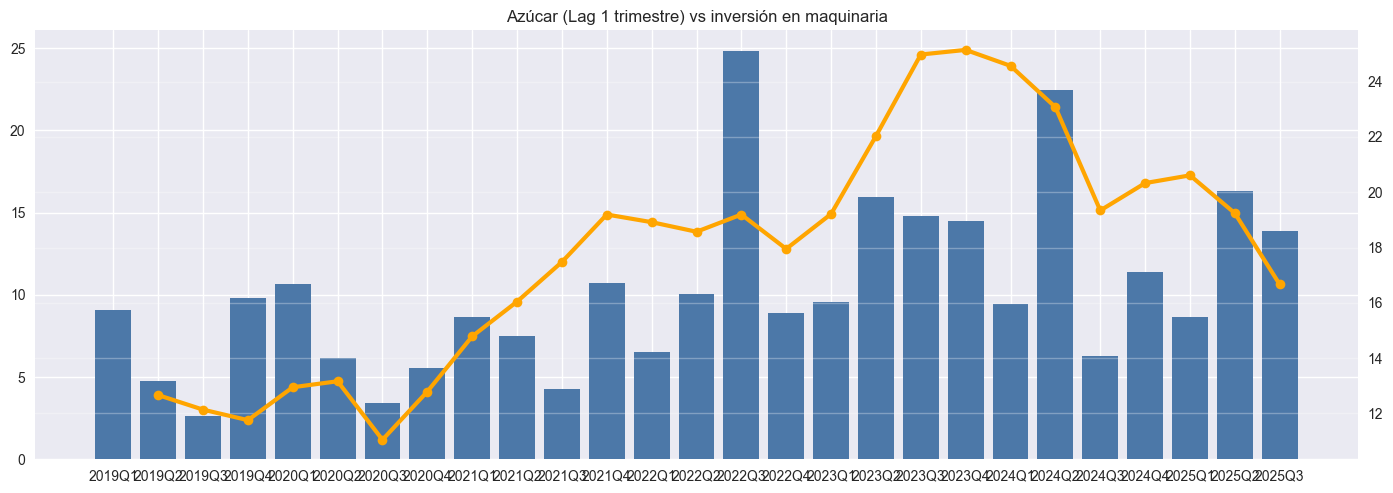

C:\Users\andres.hernandez\AppData\Local\Temp\ipykernel_39232\3287941582.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(x, rotation=90)


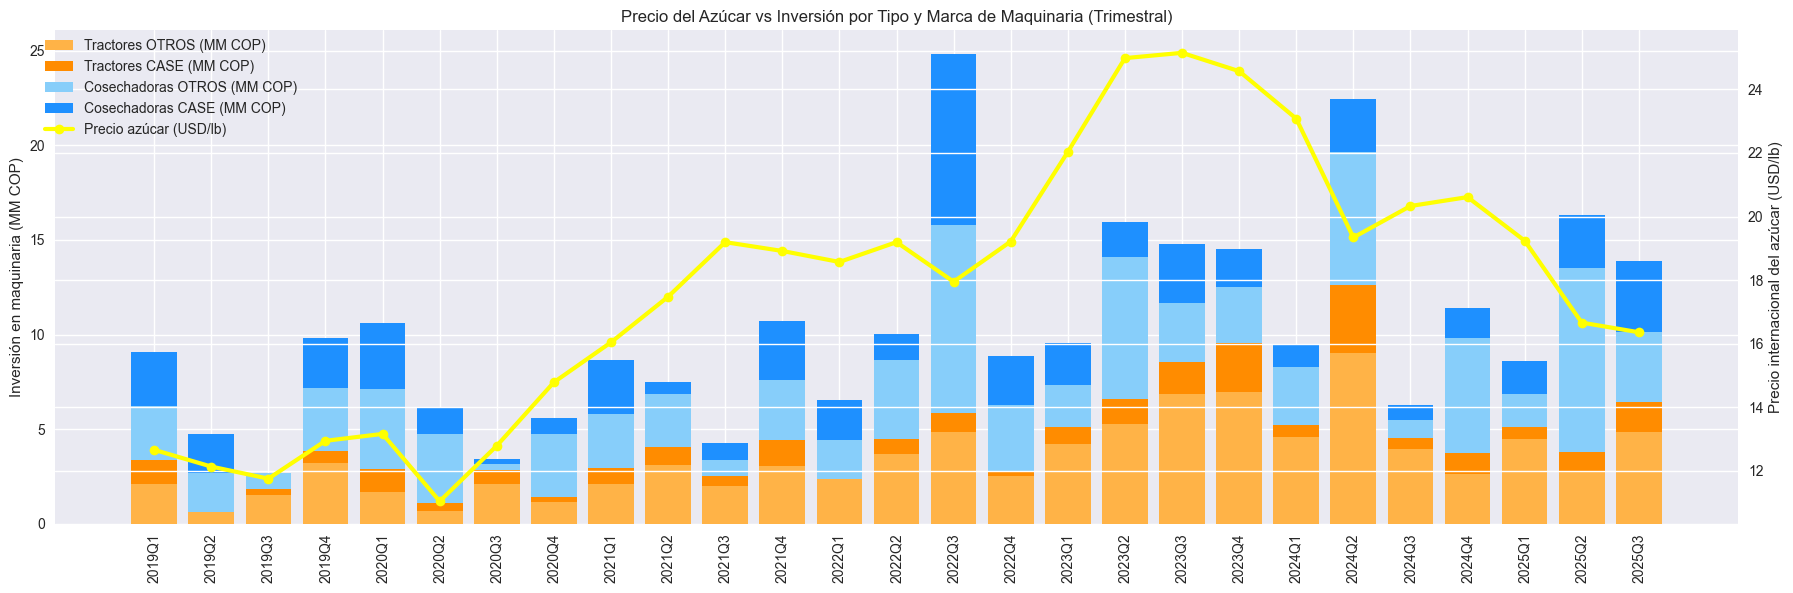

In [35]:
# ============================================================
# PARTE 5: GRÁFICOS
#   5.1 Tendencia sin lag
#   5.2 Barra + línea con lag1
#   5.3 Stacked CASE vs OTROS + azúcar
# ============================================================

# 5.1 Tendencia trimestral sin lag
plt.figure(figsize=(14,5))
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["AZUCAR"],
         label="Precio azúcar (USD/lb)", linewidth=3, color="gold")
plt.plot(df_trim["TRIMESTRE"].astype(str), df_trim["TOTAL_MAQUINARIA"]/1e6,
         label="Total maquinaria (MM COP)", linewidth=3, color="steelblue")
plt.title("Tendencia trimestral: Precio del azúcar vs inversión en maquinaria (sin lag)")
plt.xticks(rotation=90)
plt.ylabel("Precio / Inversión (MM COP)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5.2 Lag1: barras de total maquinaria + línea de azúcar rezagado
plt.figure(figsize=(14,5))
plt.bar(df_trim_lag["TRIMESTRE"].astype(str),
        df_trim_lag["TOTAL_MAQUINARIA"]/1e6,
        label="Total maquinaria (MM COP)", color="#4C78A8")
ax2 = plt.twinx()
ax2.plot(df_trim_lag["TRIMESTRE"].astype(str),
         df_trim_lag["AZUCAR_LAG1"],
         label="Azúcar Lag 1 (USD/lb)", color="orange", linewidth=3, marker="o")
plt.title("Azúcar (Lag 1 trimestre) vs inversión en maquinaria")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5.3 Gráfico completo CASE vs OTROS + azúcar (sin lag en este caso)
df_trim_det = df.groupby("TRIMESTRE").agg({
    "AZUCAR": "mean",
    "TRACTORES_OTROS": "sum",
    "TRACTORES_CASE": "sum",
    "COSECHADORAS_OTROS": "sum",
    "COSECHADORAS_CASE": "sum"
}).reset_index()

x = df_trim_det["TRIMESTRE"].astype(str)
fig, ax1 = plt.subplots(figsize=(18,6))

ax1.bar(x, df_trim_det["TRACTORES_OTROS"]/1e6,
        label="Tractores OTROS (MM COP)", color="#ffb347")
ax1.bar(x, df_trim_det["TRACTORES_CASE"]/1e6,
        bottom=df_trim_det["TRACTORES_OTROS"]/1e6,
        label="Tractores CASE (MM COP)", color="#ff8c00")

ax1.bar(x, df_trim_det["COSECHADORAS_OTROS"]/1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"]+df_trim_det["TRACTORES_CASE"])/1e6,
        label="Cosechadoras OTROS (MM COP)", color="#87CEFA")

ax1.bar(x, df_trim_det["COSECHADORAS_CASE"]/1e6,
        bottom=(df_trim_det["TRACTORES_OTROS"]+df_trim_det["TRACTORES_CASE"]
                + df_trim_det["COSECHADORAS_OTROS"])/1e6,
        label="Cosechadoras CASE (MM COP)", color="#1E90FF")

ax1.set_ylabel("Inversión en maquinaria (MM COP)")
ax1.set_xticklabels(x, rotation=90)

ax2 = ax1.twinx()
ax2.plot(x, df_trim_det["AZUCAR"], color="yellow", linewidth=3, marker="o",
         label="Precio azúcar (USD/lb)")
ax2.set_ylabel("Precio internacional del azúcar (USD/lb)")

fig.legend(loc="upper left", bbox_to_anchor=(0.02, 0.95))
plt.title("Precio del Azúcar vs Inversión por Tipo y Marca de Maquinaria (Trimestral)")
plt.tight_layout()
plt.show()
